In [2]:
print('hello')

hello


In [3]:
pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [4]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 72.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 50.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 29.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 97.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

In [5]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
1
Tesla T4


In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0))

cuda:0
Tesla T4


=== BASIC SHAPE ===
X_train: (55000, 66)
y_train: (55000, 6)
Feature cols: 66
Unique IDs: 55000

=== SEQUENCE LENGTH DISTRIBUTION ===
count    55000.000000
mean        13.892055
std          7.039313
min          3.000000
25%         10.000000
50%         13.000000
75%         16.000000
max         66.000000
Name: seq_len, dtype: float64

Min seq_len: 3
Max seq_len: 66
Median seq_len: 13.0


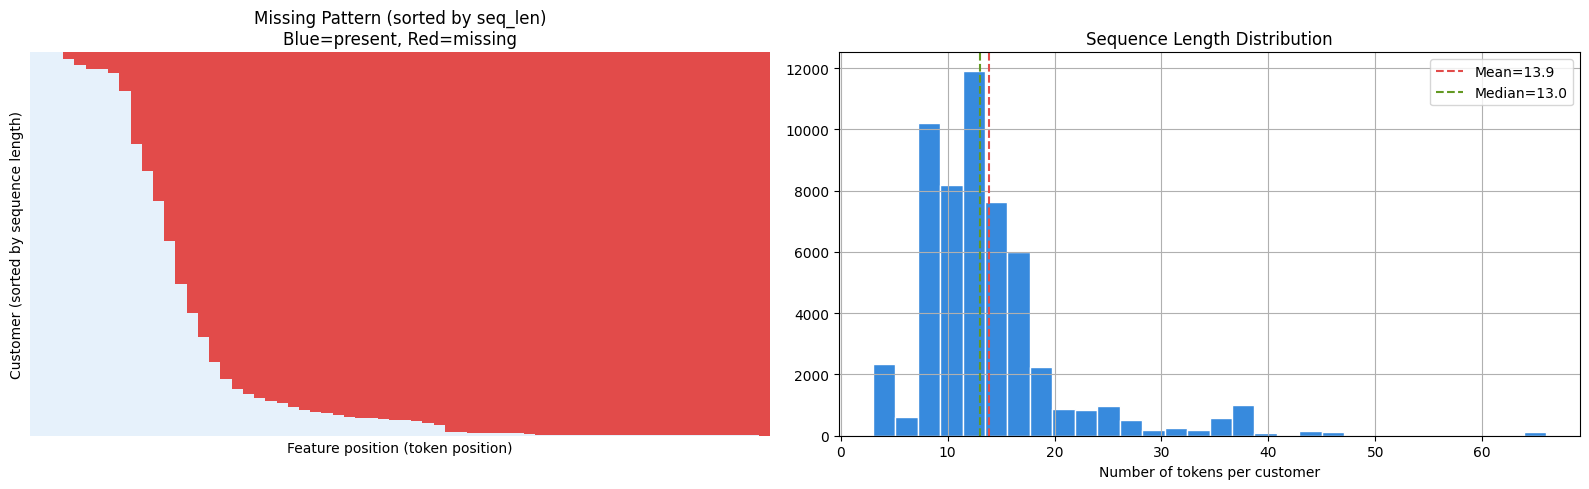


=== PADDING STRUCTURE ===
Right-padded rows: 55000 / 55000 (100.0%)
Irregular rows: 0


In [7]:
# ============================================================
# DATAFLOW 2026 — EDA NOTEBOOK
# Phase 1: Structural Understanding
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# --- Load data ---
X_train = pd.read_csv('data/X_train.csv', index_col='id')
X_train = X_train.apply(pd.to_numeric, errors='coerce')

# đổi toàn bộ sang kiểu int nullable của pandas
X_train = X_train.astype('Int64')
y_train = pd.read_csv('data/Y_train.csv', index_col='id')

# Align index
assert set(X_train.index) == set(y_train.index), "Index mismatch!"
y_train = y_train.loc[X_train.index]

print("=== BASIC SHAPE ===")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Feature cols: {X_train.shape[1]}")
print(f"Unique IDs: {X_train.index.nunique()}")

# --- Variable-length sequence: count non-null per row ---
# Each row = one customer session, features are token sequence (padded with NaN)
X_train['seq_len'] = X_train.notna().sum(axis=1)

print("\n=== SEQUENCE LENGTH DISTRIBUTION ===")
print(X_train['seq_len'].describe())
print(f"\nMin seq_len: {X_train['seq_len'].min()}")
print(f"Max seq_len: {X_train['seq_len'].max()}")
print(f"Median seq_len: {X_train['seq_len'].median()}")

# --- Missing value heatmap (show sparsity structure) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap: rows sorted by seq_len để thấy triangular missing pattern
sorted_idx = X_train.sort_values('seq_len').index
miss_matrix = X_train.loc[sorted_idx].drop('seq_len', axis=1).isna().astype(int)
sns.heatmap(miss_matrix, ax=axes[0], cbar=False,
            cmap=['#E6F1FB', '#E24B4A'], xticklabels=False, yticklabels=False)
axes[0].set_title('Missing Pattern (sorted by seq_len)\nBlue=present, Red=missing')
axes[0].set_xlabel('Feature position (token position)')
axes[0].set_ylabel('Customer (sorted by sequence length)')

# Distribution of seq_len
X_train['seq_len'].hist(bins=30, ax=axes[1], color='#378ADD', edgecolor='white')
axes[1].axvline(X_train['seq_len'].mean(), color='#E24B4A', linestyle='--', label=f"Mean={X_train['seq_len'].mean():.1f}")
axes[1].axvline(X_train['seq_len'].median(), color='#639922', linestyle='--', label=f"Median={X_train['seq_len'].median():.1f}")
axes[1].set_title('Sequence Length Distribution')
axes[1].set_xlabel('Number of tokens per customer')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase1_structure.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Key insight check: is missing pattern truly "right-padded"? ---
# Expect: for each row, NaN appear only AFTER the last valid value (right-padded)
def is_right_padded(row):
    vals = row.values
    seen_nan = False
    for v in vals:
        if pd.isna(v):
            seen_nan = True
        elif seen_nan:
            return False  # non-NaN after NaN = NOT right-padded
    return True

feature_cols = [c for c in X_train.columns if c != 'seq_len']
pad_check = X_train[feature_cols].apply(is_right_padded, axis=1)
print(f"\n=== PADDING STRUCTURE ===")
print(f"Right-padded rows: {pad_check.sum()} / {len(pad_check)} ({pad_check.mean()*100:.1f}%)")
print(f"Irregular rows: {(~pad_check).sum()}")
# If > 0 irregular: those are anomalies to investigate in Phase 5

=== TOKEN VOCABULARY ===
Unique tokens: 833
Total token occurrences: 764063

Top 20 most frequent tokens:
     102  →   47063 times  (6.16%)
     105  →   44746 times  (5.86%)
     103  →   25436 times  (3.33%)
     760  →   15206 times  (1.99%)
    8615  →   14960 times  (1.96%)
     606  →   14073 times  (1.84%)
     685  →   13192 times  (1.73%)
     697  →   11519 times  (1.51%)
     867  →    9334 times  (1.22%)
     929  →    9257 times  (1.21%)
     975  →    8762 times  (1.15%)
   21040  →    8379 times  (1.10%)
     621  →    8291 times  (1.09%)
   20022  →    8158 times  (1.07%)
   21355  →    8126 times  (1.06%)
   21606  →    8125 times  (1.06%)
   17980  →    8115 times  (1.06%)
   20278  →    8101 times  (1.06%)
   15342  →    8072 times  (1.06%)
    1068  →    7602 times  (0.99%)

Bottom 10 rarest tokens:
    4843  →       1 times
    2615  →       1 times
    7082  →       1 times
    8599  →       1 times
   16838  →       1 times
    4951  →       1 times
   15016  → 

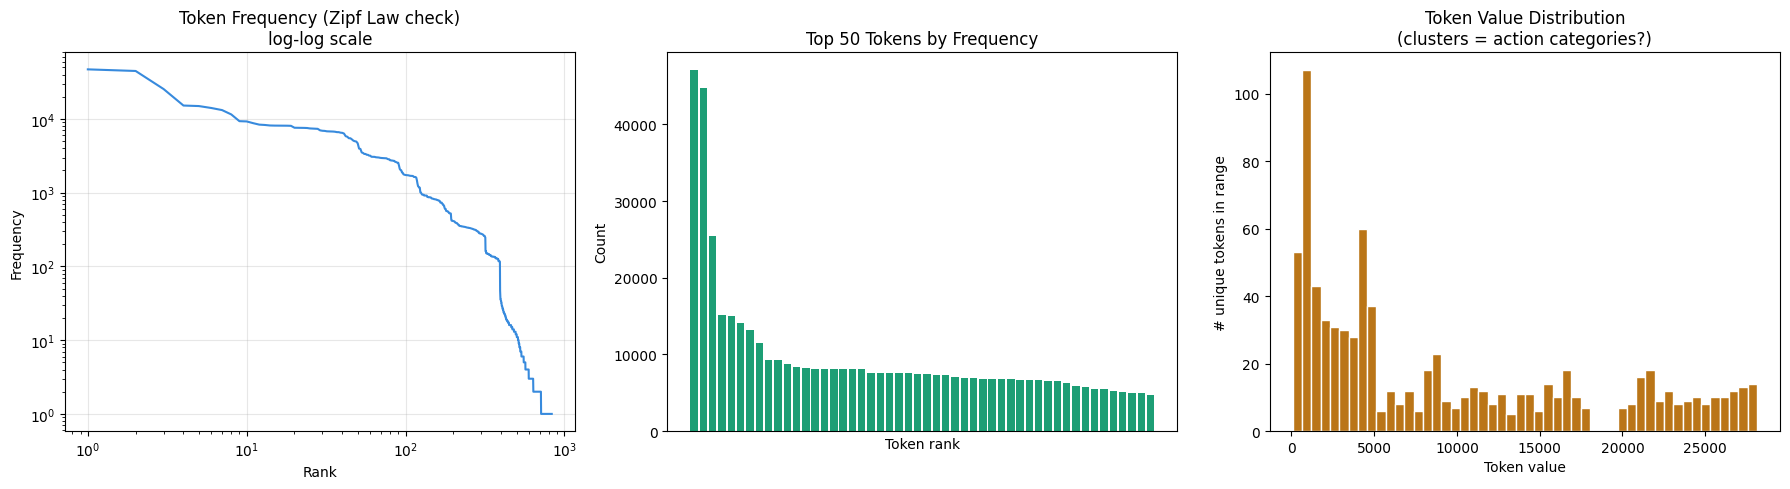


=== POSITIONAL TOKEN ANALYSIS ===
Unique first tokens: 159
Top 5 first tokens: [(np.int64(760), 6319), (np.int64(1076), 6210), (np.int64(685), 6030), (np.int64(10477), 3248), (np.int64(7943), 3123)]

Unique last tokens: 176
Top 5 last tokens: [(np.int64(104), 3245), (np.int64(975), 3051), (np.int64(1071), 3045), (np.int64(1045), 3030), (np.int64(977), 2972)]


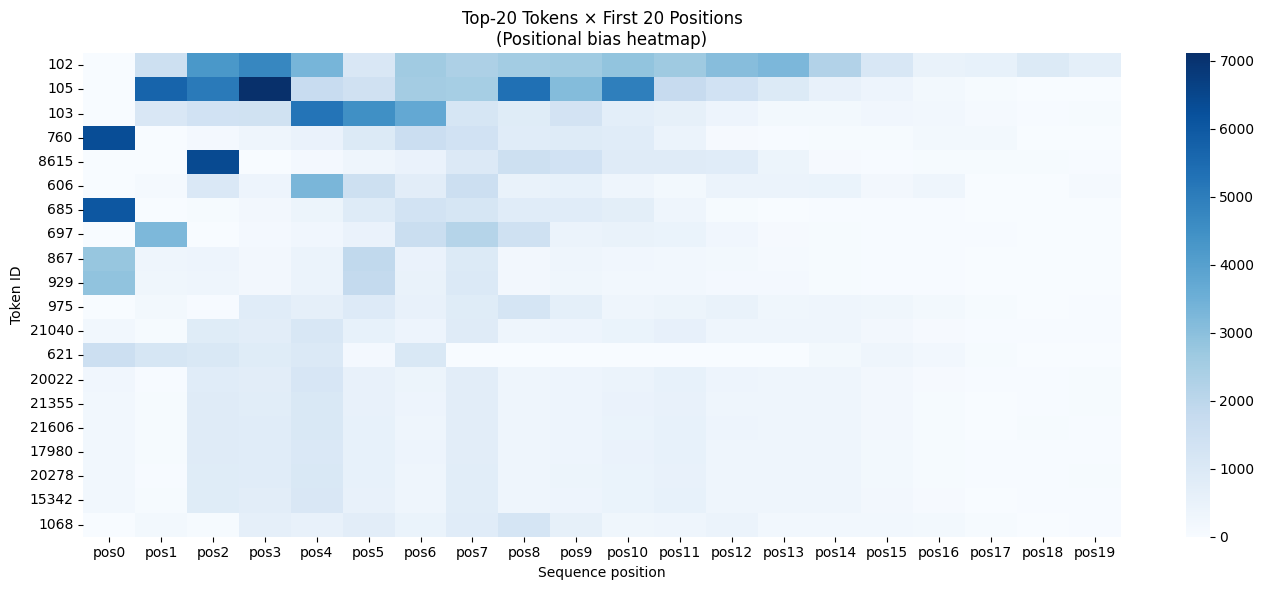

In [8]:
# ============================================================
# Phase 2: Token-level Analysis
# ============================================================

# --- Extract all tokens (flatten sequences) ---
flat_tokens = []
positional_tokens = defaultdict(list)  # position -> list of tokens

for idx, row in X_train[feature_cols].iterrows():
    tokens = row.dropna().values
    for pos, tok in enumerate(tokens):
        flat_tokens.append(tok)
        positional_tokens[pos].append(tok)

flat_tokens = np.array(flat_tokens, dtype=float)

print("=== TOKEN VOCABULARY ===")
token_counts = Counter(flat_tokens)
vocab = sorted(token_counts.keys())
print(f"Unique tokens: {len(vocab)}")
print(f"Total token occurrences: {len(flat_tokens)}")
print(f"\nTop 20 most frequent tokens:")
for tok, cnt in token_counts.most_common(20):
    print(f"  {int(tok):6d}  →  {cnt:6d} times  ({cnt/len(flat_tokens)*100:.2f}%)")

print(f"\nBottom 10 rarest tokens:")
for tok, cnt in token_counts.most_common()[-10:]:
    print(f"  {int(tok):6d}  →  {cnt:6d} times")

# --- Token frequency distribution (power law?) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Token frequency rank plot (log-log)
freqs = sorted([v for v in token_counts.values()], reverse=True)
axes[0].loglog(range(1, len(freqs)+1), freqs, color='#378ADD', linewidth=1.5)
axes[0].set_title('Token Frequency (Zipf Law check)\nlog-log scale')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# 2. Top-50 token bar chart
top50 = token_counts.most_common(50)
tok_labels = [str(int(t[0])) for t in top50]
tok_freqs = [t[1] for t in top50]
axes[1].bar(range(50), tok_freqs, color='#1D9E75', edgecolor='none')
axes[1].set_title('Top 50 Tokens by Frequency')
axes[1].set_xlabel('Token rank')
axes[1].set_ylabel('Count')
axes[1].set_xticks([])

# 3. Token value distribution (are tokens clustered in ranges?)
axes[2].hist(vocab, bins=50, color='#BA7517', edgecolor='white')
axes[2].set_title('Token Value Distribution\n(clusters = action categories?)')
axes[2].set_xlabel('Token value')
axes[2].set_ylabel('# unique tokens in range')

plt.tight_layout()
plt.savefig('phase2_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Positional bias: does token type vary by position? ---
# First token vs middle vs last token distribution
print("\n=== POSITIONAL TOKEN ANALYSIS ===")
first_tokens = Counter(X_train[feature_cols[0]].dropna().values)
print(f"Unique first tokens: {len(first_tokens)}")
print(f"Top 5 first tokens: {first_tokens.most_common(5)}")

# Get last token for each sequence
def get_last_token(row):
    vals = row.dropna().values
    return vals[-1] if len(vals) > 0 else np.nan

last_tokens = X_train[feature_cols].apply(get_last_token, axis=1)
last_tok_counts = Counter(last_tokens.dropna().values)
print(f"\nUnique last tokens: {len(last_tok_counts)}")
print(f"Top 5 last tokens: {last_tok_counts.most_common(5)}")

# --- Positional heatmap: top-20 tokens across first 20 positions ---
top20_tokens = [t[0] for t in token_counts.most_common(20)]
pos_matrix = np.zeros((20, 20))  # [token_idx, position]
for pos in range(20):
    if pos in positional_tokens:
        pos_cnt = Counter(positional_tokens[pos])
        for ti, tok in enumerate(top20_tokens):
            pos_matrix[ti, pos] = pos_cnt.get(tok, 0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pos_matrix, ax=ax, cmap='Blues',
            xticklabels=[f'pos{i}' for i in range(20)],
            yticklabels=[str(int(t)) for t in top20_tokens])
ax.set_title('Top-20 Tokens × First 20 Positions\n(Positional bias heatmap)')
ax.set_xlabel('Sequence position')
ax.set_ylabel('Token ID')
plt.tight_layout()
plt.savefig('phase2_positional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Extracting behavioral features...
Behavioral feature matrix: (55000, 28)
        seq_len  log_seq_len  unique_tokens  unique_ratio  token_mean  \
count  55000.00     55000.00       55000.00      55000.00    55000.00   
mean      13.89         2.61          12.01          0.88     3771.12   
std        7.04         0.41           5.61          0.10     1597.25   
min        3.00         1.39           2.00          0.38      291.56   
25%       10.00         2.40           9.00          0.81     2446.64   
50%       13.00         2.64          10.00          0.90     3828.74   
75%       16.00         2.83          14.00          0.95     4951.10   
max       66.00         4.20          47.00          1.00     9097.40   

       token_std  token_median  token_min  token_max  token_range  ...  \
count   55000.00      55000.00   55000.00   55000.00     55000.00  ...   
mean     5559.95       1056.43     128.49   17403.97     17275.48  ...   
std      2287.85        546.25     112.52    65

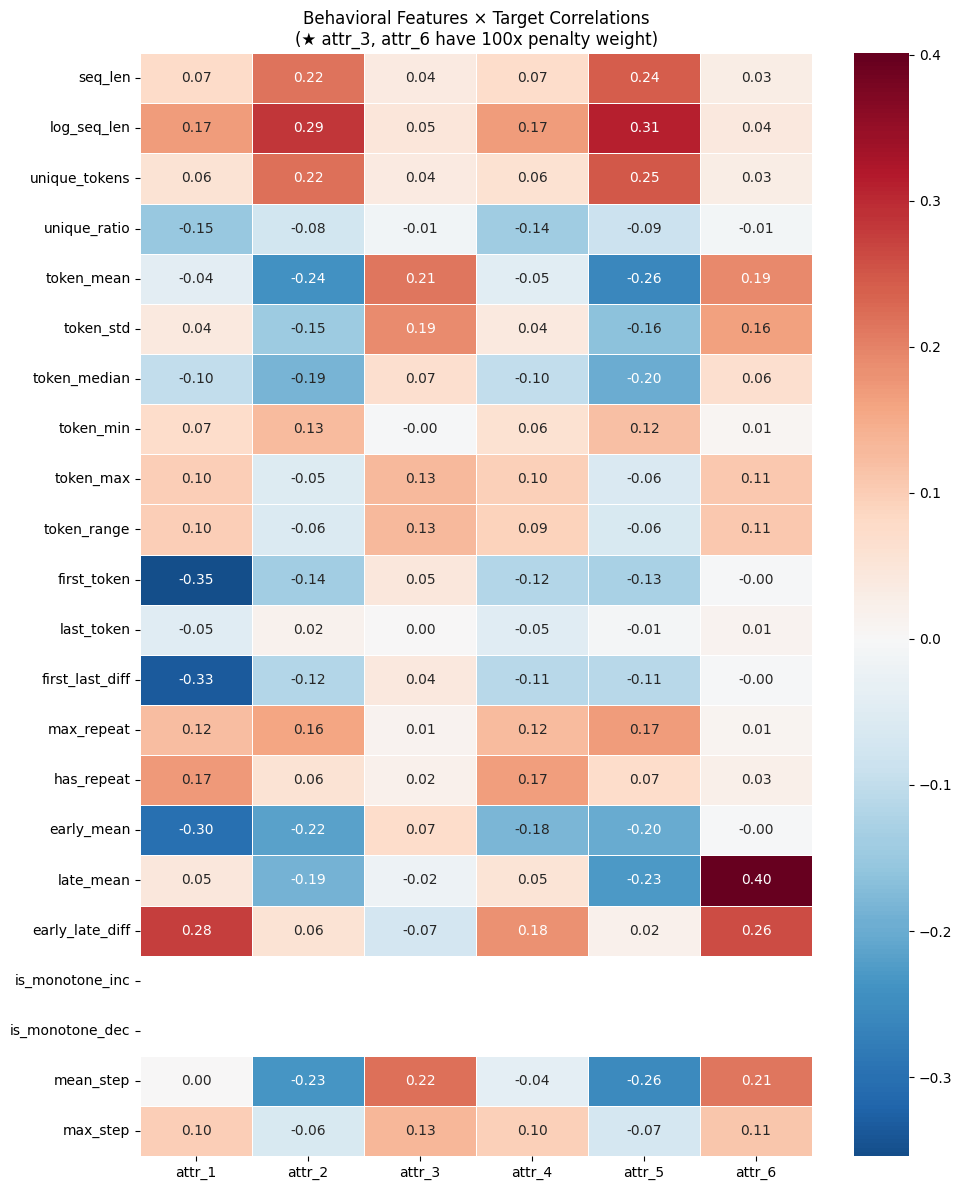


=== BEHAVIORAL PERSONAS (CLUSTERING) ===


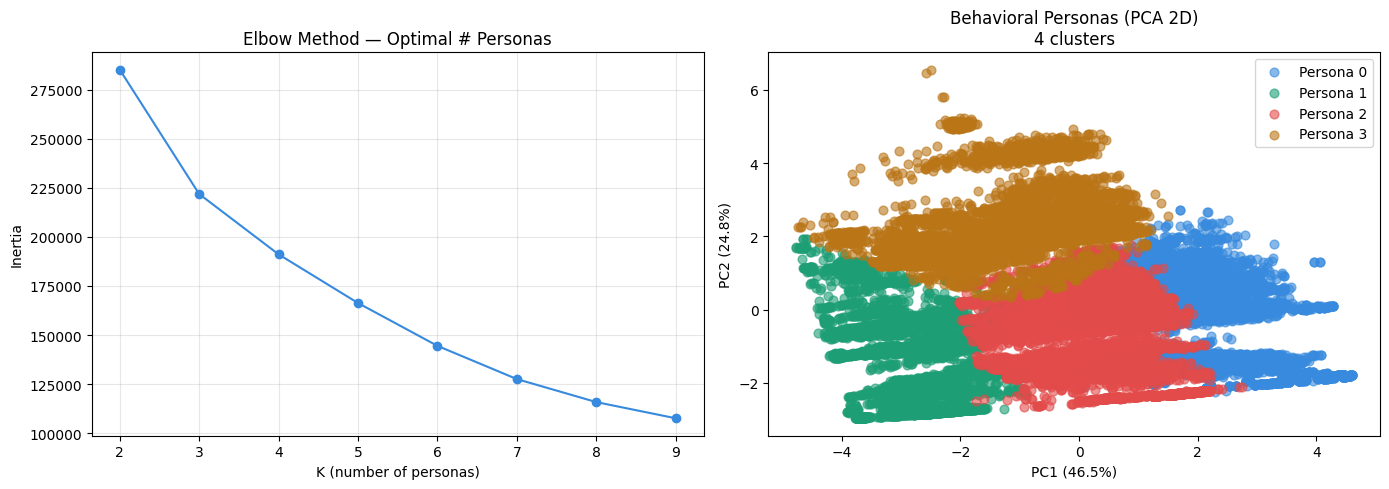


=== PERSONA PROFILES ===
persona                 0        1         2         3
seq_len             11.80    11.65     14.87     19.16
unique_ratio         0.90     0.91      0.93      0.74
token_mean        5170.42  1629.65   3774.22   2840.27
token_std         7391.58  1725.67   5888.38   4896.03
mean_step         9101.40  1988.02   5830.77   4866.44
max_step         20890.39  5204.28  19201.69  16802.98
early_late_diff   3731.48   293.79  -1677.81   1434.94
max_repeat           1.77     1.74      1.69      3.78
attr_1               7.60     6.35      6.83      7.67
attr_2              10.16    13.99     12.72     15.76
attr_3              53.88    44.30     47.40     50.26
attr_4               7.44     6.43      7.14      7.72
attr_5              10.00    14.36     13.04     16.24
attr_6              59.00    46.07     38.45     50.10


In [9]:
# ============================================================
# Phase 3: Behavioral Profiling & Persona Discovery
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import scipy.stats as stats

# --- Feature extraction từ sequences (behavioral features) ---
def extract_behavioral_features(row_tokens):
    """Extract rich behavioral features from a variable-length token sequence."""
    tokens = np.array(row_tokens, dtype=float)
    n = len(tokens)
    if n == 0:
        return {}

    tok_int = tokens.astype(int)

    feats = {
        # --- Volume / Intensity ---
        'seq_len': n,
        'log_seq_len': np.log1p(n),

        # --- Token diversity ---
        'unique_tokens': len(set(tok_int)),
        'unique_ratio': len(set(tok_int)) / n,  # entropy proxy

        # --- Value statistics ---
        'token_mean': tokens.mean(),
        'token_std': tokens.std() if n > 1 else 0,
        'token_median': np.median(tokens),
        'token_min': tokens.min(),
        'token_max': tokens.max(),
        'token_range': tokens.max() - tokens.min(),

        # --- Temporal dynamics ---
        'first_token': tokens[0],
        'last_token': tokens[-1],
        'first_last_diff': abs(tokens[-1] - tokens[0]),

        # --- Repetition behavior ---
        'max_repeat': max(Counter(tok_int).values()),
        'has_repeat': int(max(Counter(tok_int).values()) > 1),

        # --- Position-weighted stats ---
        'early_mean': tokens[:max(1, n//4)].mean(),   # first 25%
        'late_mean': tokens[max(0, 3*n//4):].mean(),  # last 25%
        'early_late_diff': tokens[max(0, 3*n//4):].mean() - tokens[:max(1, n//4)].mean(),

        # --- Monotonicity ---
        'is_monotone_inc': int(all(tokens[i] <= tokens[i+1] for i in range(n-1))) if n > 1 else 0,
        'is_monotone_dec': int(all(tokens[i] >= tokens[i+1] for i in range(n-1))) if n > 1 else 0,

        # --- Transition stats ---
        'mean_step': np.mean(np.abs(np.diff(tokens))) if n > 1 else 0,
        'max_step': np.max(np.abs(np.diff(tokens))) if n > 1 else 0,
    }
    return feats

# Apply to all customers
print("Extracting behavioral features...")
behavioral_rows = []
for idx, row in X_train[feature_cols].iterrows():
    toks = row.dropna().values
    feats = extract_behavioral_features(toks)
    feats['id'] = idx
    behavioral_rows.append(feats)

behavioral_df = pd.DataFrame(behavioral_rows).set_index('id')
behavioral_df = behavioral_df.join(y_train)

print(f"Behavioral feature matrix: {behavioral_df.shape}")
print(behavioral_df.describe().round(2))

# --- Correlation: behavioral features vs each output ---
print("\n=== CORRELATION WITH TARGETS ===")
target_cols = ['attr_1','attr_2','attr_3','attr_4','attr_5','attr_6']
feat_cols_for_corr = [c for c in behavioral_df.columns if c not in target_cols]

corr_df = behavioral_df[feat_cols_for_corr + target_cols].corr()[target_cols].loc[feat_cols_for_corr]
print("Top correlations with attr_3 (w=100):")
print(corr_df['attr_3'].abs().sort_values(ascending=False).head(10))
print("\nTop correlations with attr_6 (w=100):")
print(corr_df['attr_6'].abs().sort_values(ascending=False).head(10))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(corr_df, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5)
ax.set_title('Behavioral Features × Target Correlations\n(★ attr_3, attr_6 have 100x penalty weight)')
plt.tight_layout()
plt.savefig('phase3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Behavioral Persona Discovery via Clustering ---
print("\n=== BEHAVIORAL PERSONAS (CLUSTERING) ===")
feat_for_cluster = ['seq_len', 'unique_ratio', 'token_mean', 'token_std',
                     'mean_step', 'max_step', 'early_late_diff', 'max_repeat']
X_cluster = behavioral_df[feat_for_cluster].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method for optimal K
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'o-', color='#378ADD')
axes[0].set_title('Elbow Method — Optimal # Personas')
axes[0].set_xlabel('K (number of personas)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Final clustering with chosen K (adjust after seeing elbow)
K_FINAL = 4  # replace after elbow analysis
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
behavioral_df['persona'] = km_final.fit_predict(X_scaled)

# PCA visualization of personas
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
colors = ['#378ADD', '#1D9E75', '#E24B4A', '#BA7517', '#534AB7', '#D85A30']
for p in range(K_FINAL):
    mask = behavioral_df['persona'] == p
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                     c=colors[p], label=f'Persona {p}', alpha=0.6, s=40)
axes[1].set_title(f'Behavioral Personas (PCA 2D)\n{K_FINAL} clusters')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase3_personas.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Persona profiling: describe each cluster ---
print("\n=== PERSONA PROFILES ===")
persona_profile = behavioral_df.groupby('persona')[feat_for_cluster + target_cols].mean().round(2)
print(persona_profile.T)

# Name personas based on behavior
# Example interpretation framework:
persona_names = {
    0: "High-frequency repeaters (nhiều lần tương tác, ít token mới)",
    1: "Explorers (chuỗi dài, diverse tokens)",
    2: "Quick transactors (chuỗi ngắn, ít bước)",
    3: "Irregular/anomalous (high variance)"
}
# Adjust after seeing actual cluster stats

Samples : 55000
Targets : ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']

  4.1  TARGET DISTRIBUTIONS
attr_1  |  min=1  max=12  mean=7.20  std=3.96  skew=-0.13  
attr_2  |  min=1  max=31  mean=12.50  std=9.98  skew=0.30  
attr_3  |  min=0  max=99  mean=49.94  std=28.57  skew=0.00  ★ w=100
attr_4  |  min=1  max=12  mean=7.24  std=3.96  skew=-0.14  
attr_5  |  min=1  max=31  mean=12.67  std=10.13  skew=0.30  
attr_6  |  min=0  max=99  mean=50.07  std=28.63  skew=-0.00  ★ w=100


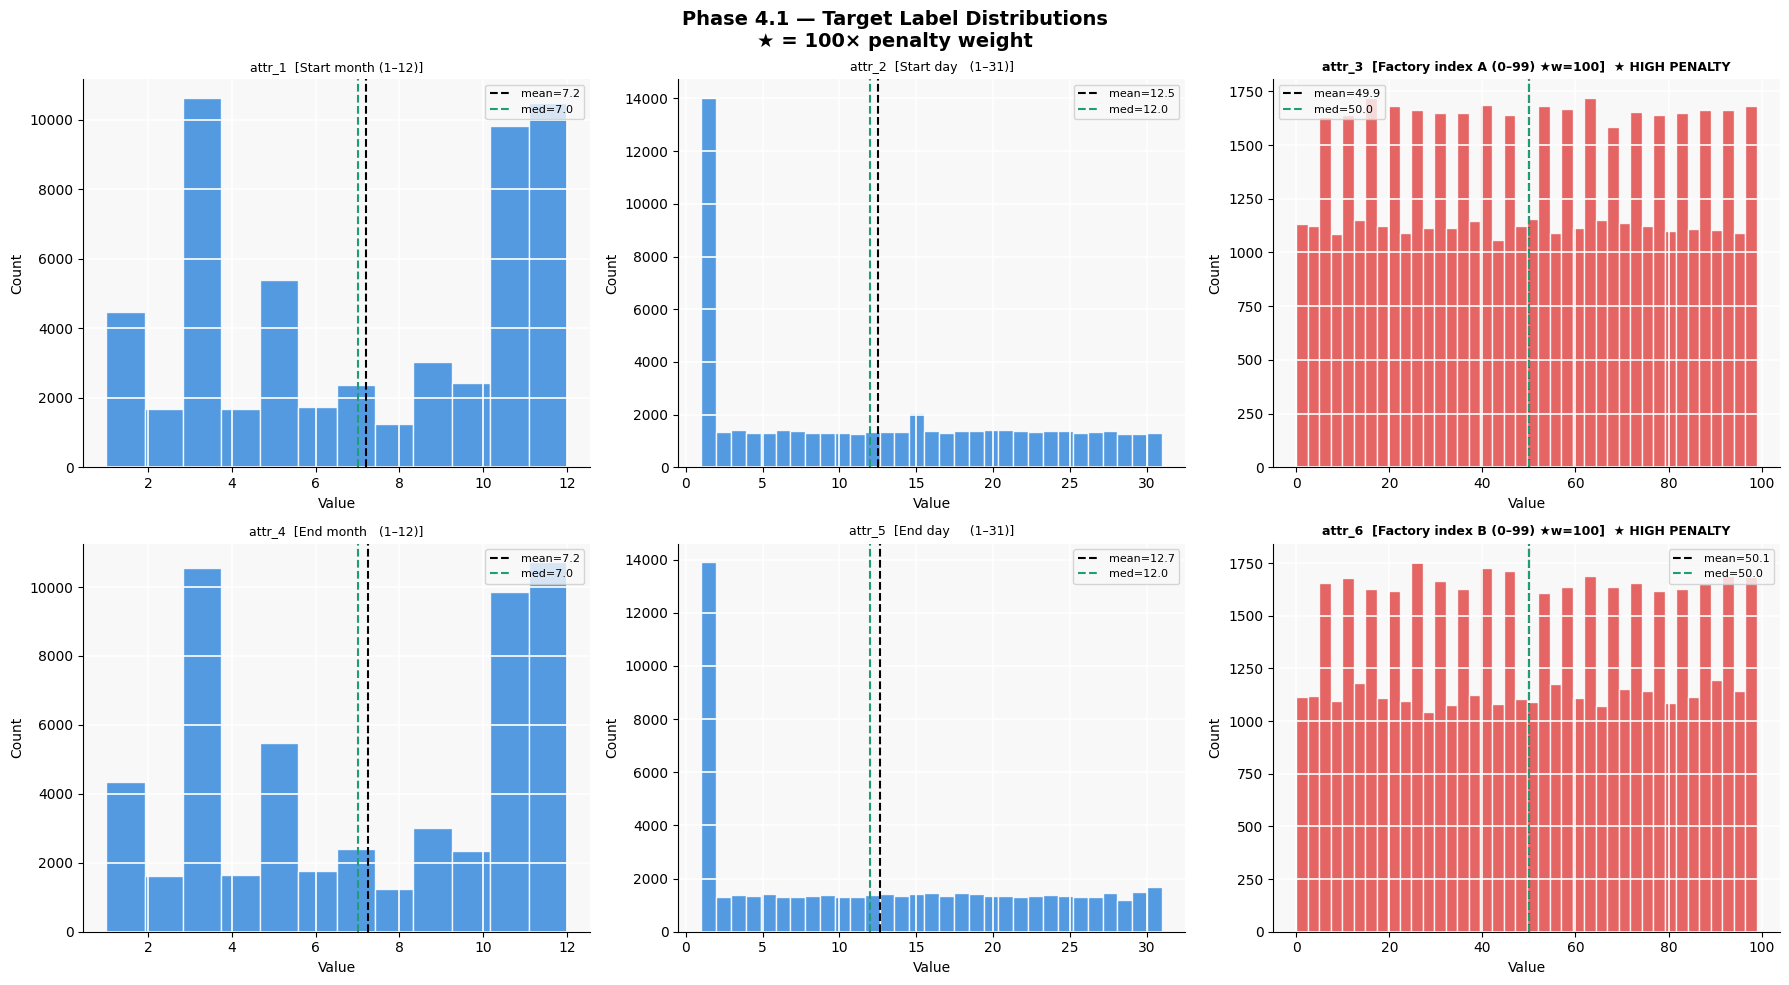

  → saved phase4_1_target_distributions.png


  4.2  PEARSON + SPEARMAN CORRELATION MATRICES


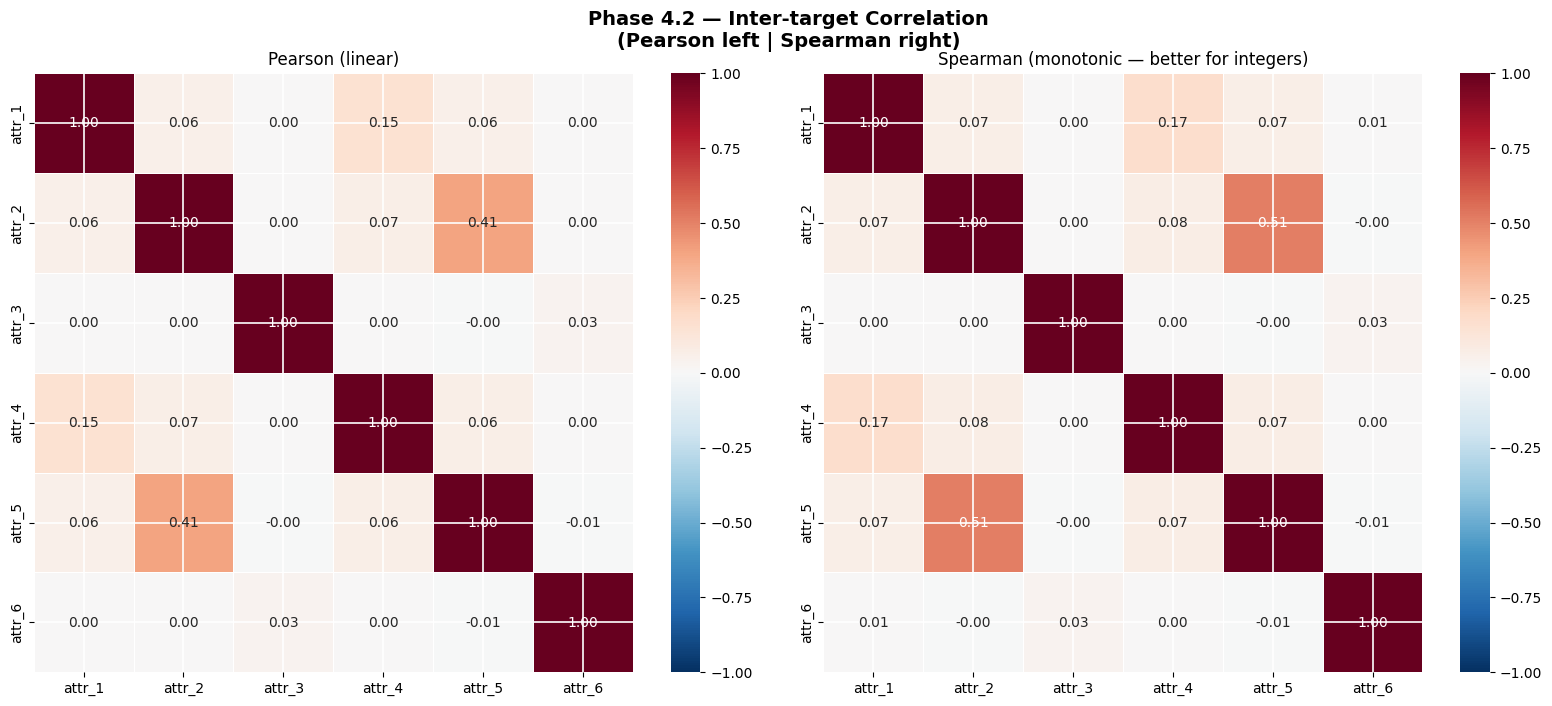

  → saved phase4_2_correlation_matrix.png

── Key pairs ──
  attr_1 ↔ attr_4  (start vs end month):  Pearson=0.154  Spearman=0.175
  attr_2 ↔ attr_5  (start vs end day):  Pearson=0.406  Spearman=0.515
  attr_3 ↔ attr_6  (factory index A vs B):  Pearson=0.034  Spearman=0.034
  attr_1 ↔ attr_2  (start month vs start day):  Pearson=0.060  Spearman=0.067
  attr_4 ↔ attr_5  (end month vs end day):  Pearson=0.063  Spearman=0.072

  4.3  PAIRPLOT — targets coloured by persona


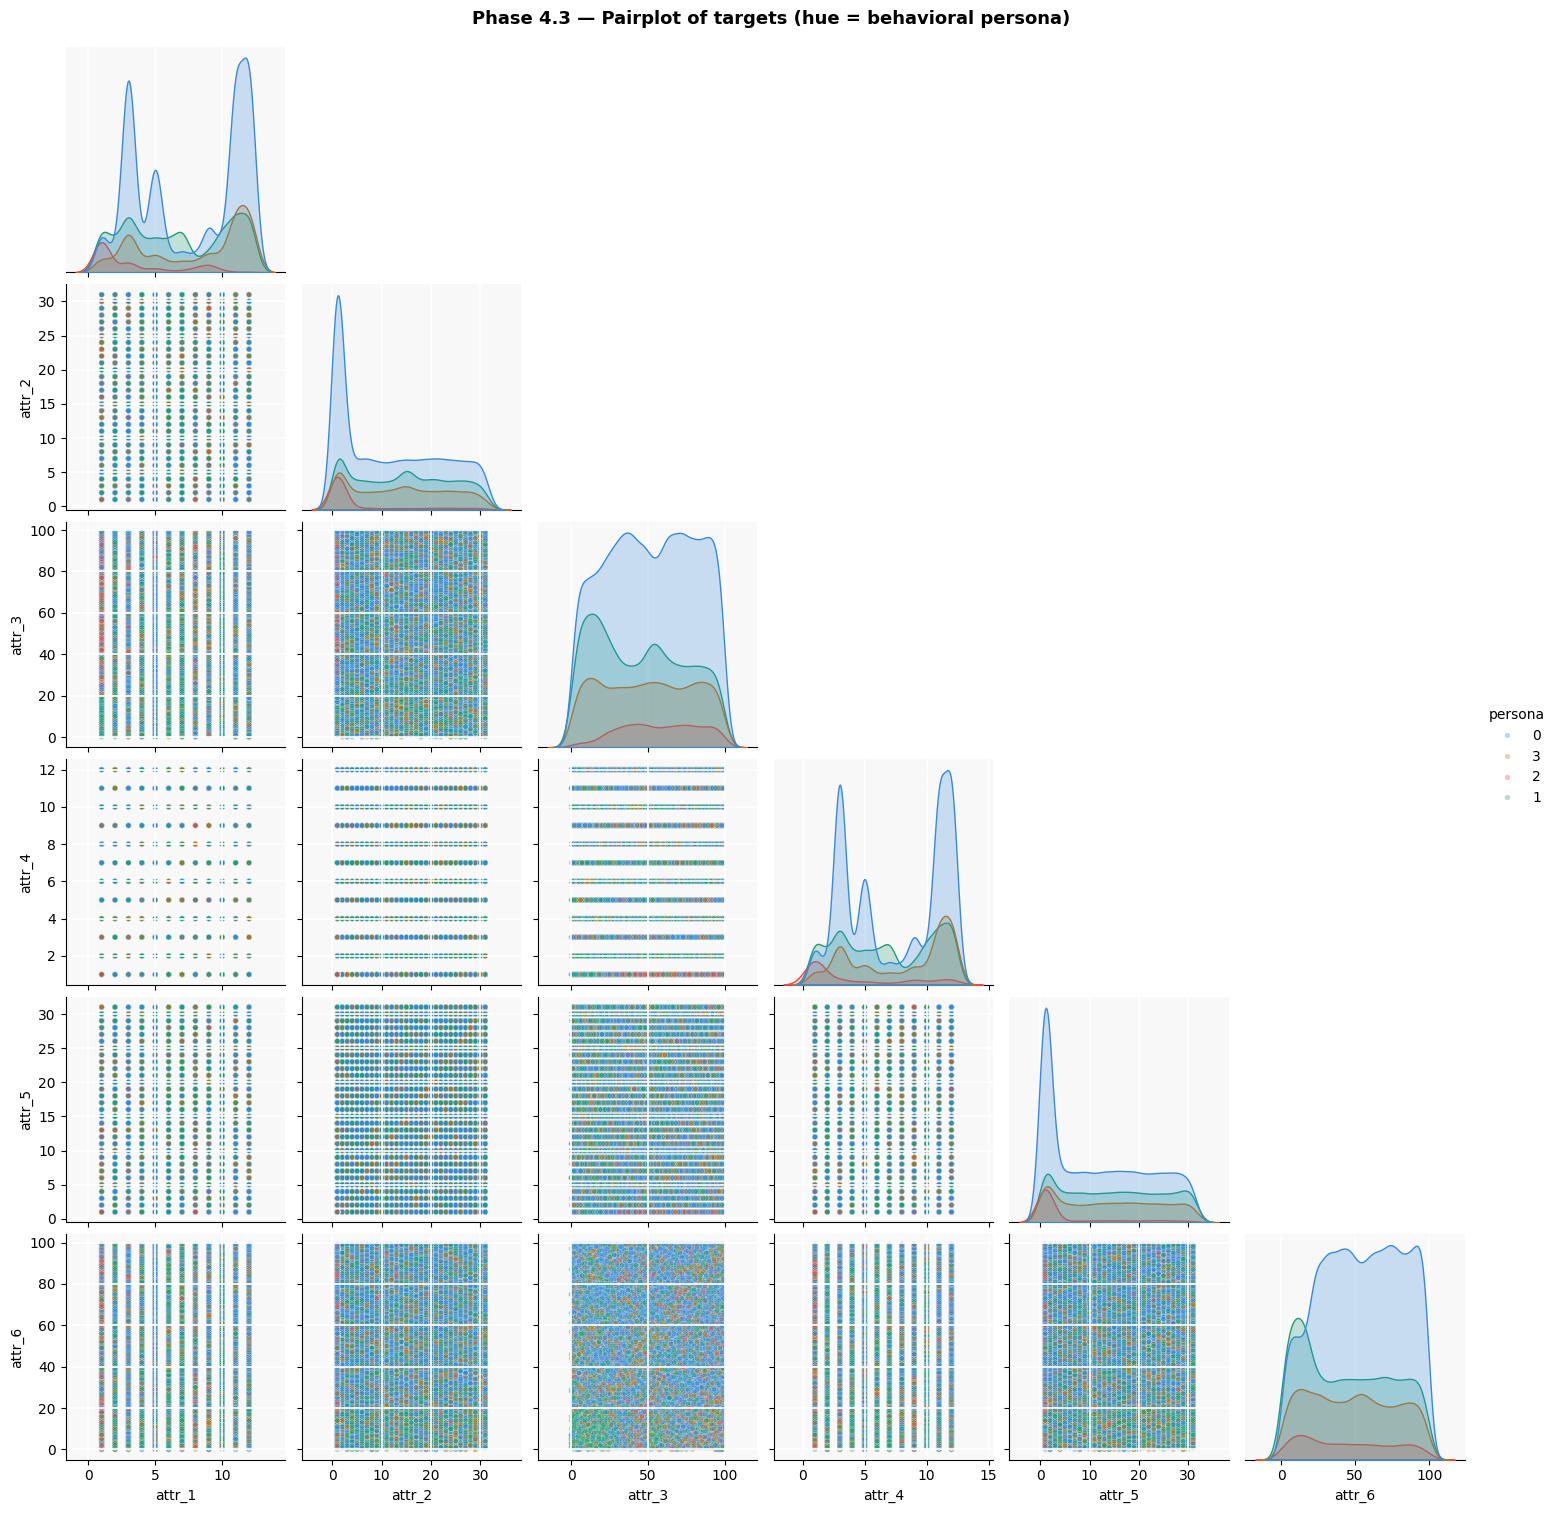

  → saved phase4_3_pairplot.png


  4.4  CONDITIONAL CORRELATION PER PERSONA
  Persona 0: max |corr_p - corr_overall| = 0.224
  Persona 1: max |corr_p - corr_overall| = 0.266
  Persona 2: max |corr_p - corr_overall| = 0.516
  Persona 3: max |corr_p - corr_overall| = 0.326


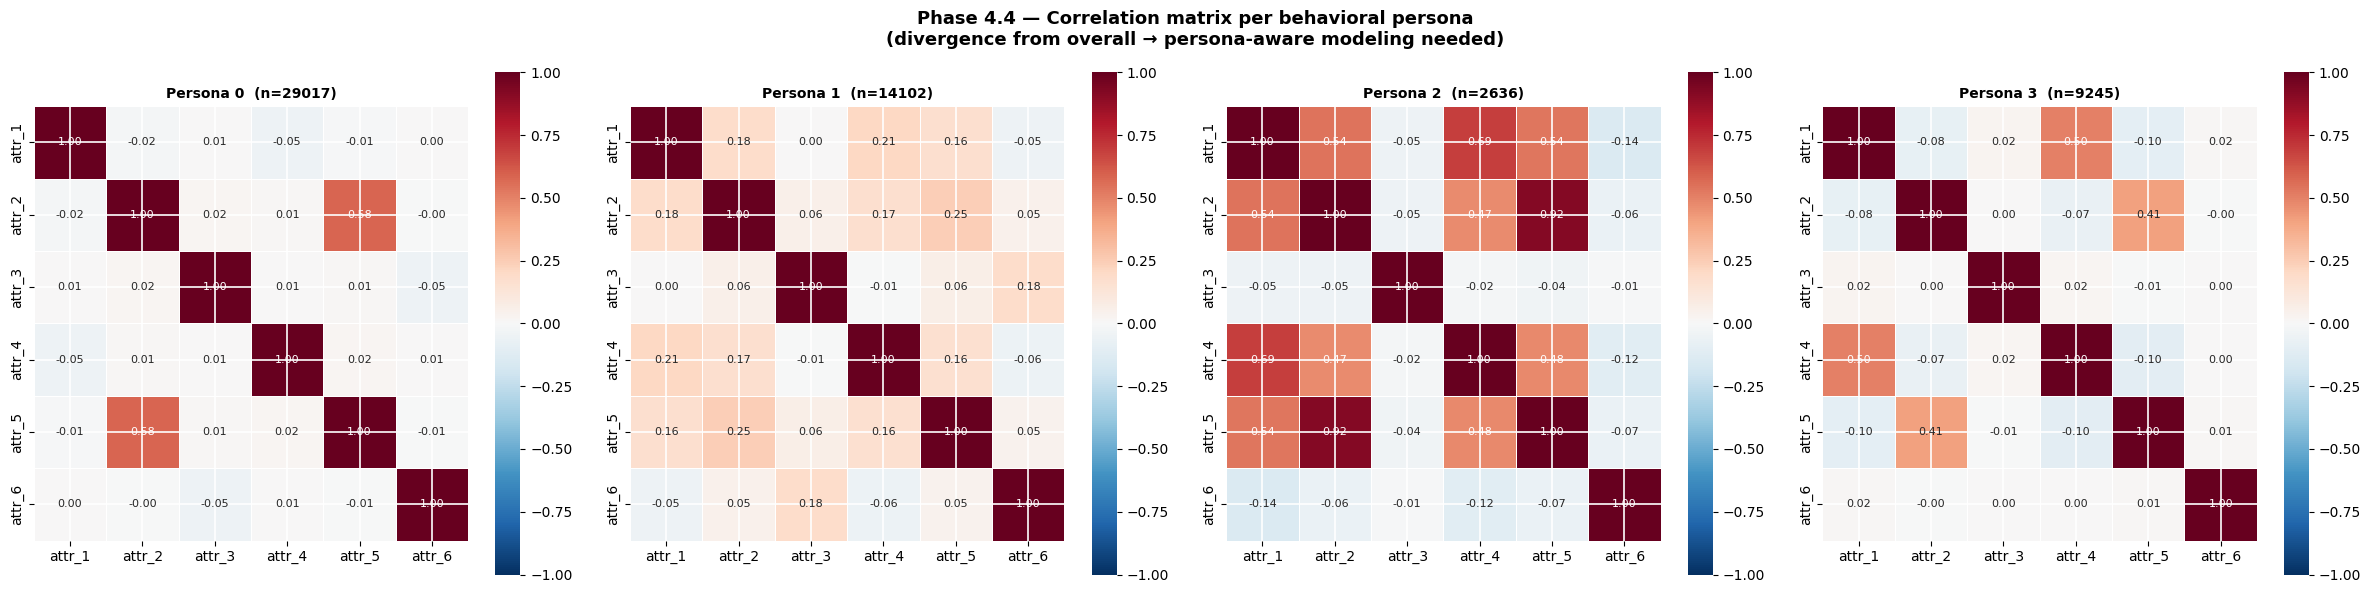

  → saved phase4_4_conditional_correlation.png

  → If divergence > 0.2: consider persona-stratified modeling

  4.5  TRANSACTION DURATION ANALYSIS
Transaction duration (approx days):
count    55000.00
mean         1.34
std        154.91
min       -358.00
25%        -82.00
50%          0.00
75%         87.00
max        357.00
Name: duration_approx, dtype: float64

Impossible durations (end < start): 24545 rows  (44.63%)
  ⚠ These rows are business-logic anomalies — flag for Phase 5


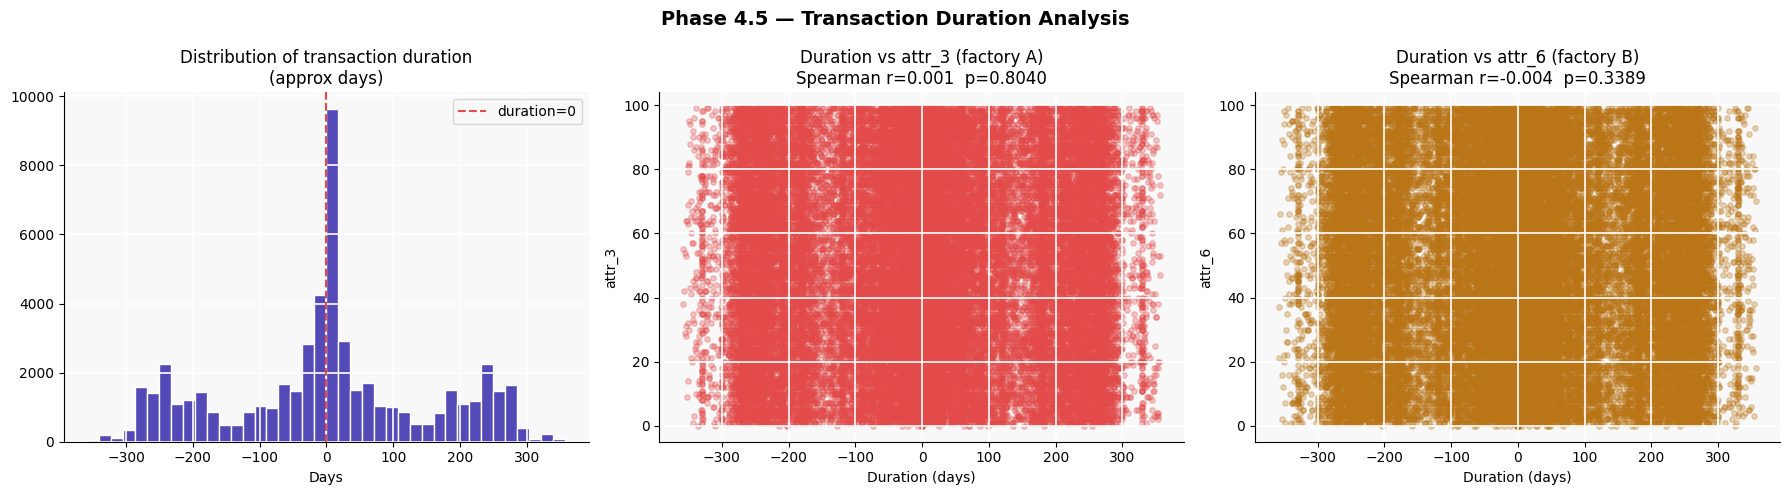

  → saved phase4_5_duration.png


Mean duration per persona:
persona
0    -1.13
1     2.47
2    25.04
3     0.59
Name: duration_approx, dtype: float64

  4.6  MUTUAL INFORMATION BETWEEN TARGETS


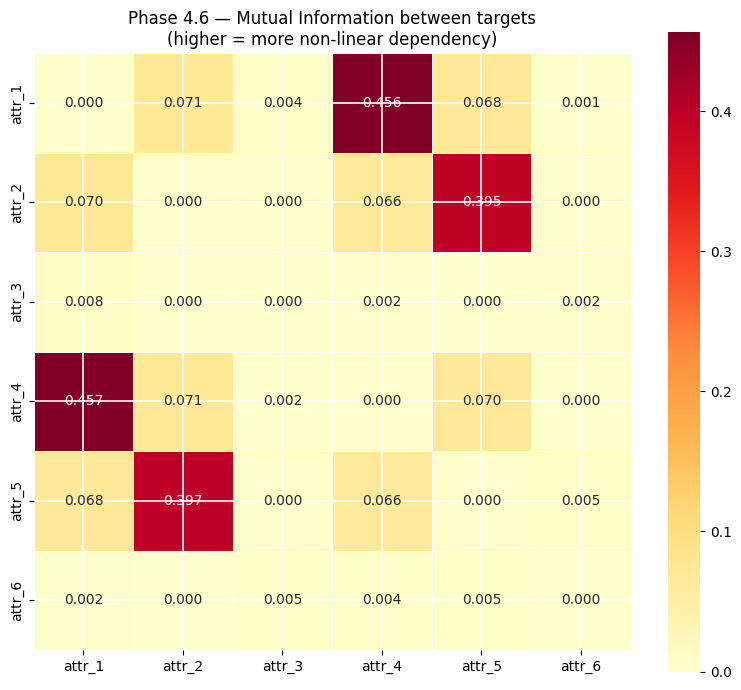

  → saved phase4_6_mutual_information.png

── Top MI pairs ──
  attr_1 ↔ attr_4:  MI=0.4559
  attr_2 ↔ attr_5:  MI=0.3954
  attr_1 ↔ attr_2:  MI=0.0707
  attr_4 ↔ attr_5:  MI=0.0695
  attr_1 ↔ attr_5:  MI=0.0683
  attr_2 ↔ attr_4:  MI=0.0663
  attr_5 ↔ attr_6:  MI=0.0046
  attr_1 ↔ attr_3:  MI=0.0042
  attr_3 ↔ attr_6:  MI=0.0021
  attr_3 ↔ attr_4:  MI=0.0016
  attr_1 ↔ attr_6:  MI=0.0013
  attr_2 ↔ attr_6:  MI=0.0004
  attr_2 ↔ attr_3:  MI=0.0000
  attr_3 ↔ attr_5:  MI=0.0000
  attr_4 ↔ attr_6:  MI=0.0000

  4.7  SEQUENCE LENGTH vs TARGETS (Spearman)
Attribute         r      p-value  Significance
--------------------------------------------------
attr_1        0.105      0.00000  ★ SIGNIFICANT
attr_2        0.329      0.00000  ★ SIGNIFICANT
attr_3        0.057      0.00000  ★ SIGNIFICANT
attr_4        0.111      0.00000  ★ SIGNIFICANT
attr_5        0.352      0.00000  ★ SIGNIFICANT
attr_6        0.052      0.00000  ★ SIGNIFICANT

Top behavioral feature correlations with attr_3 (w=100)

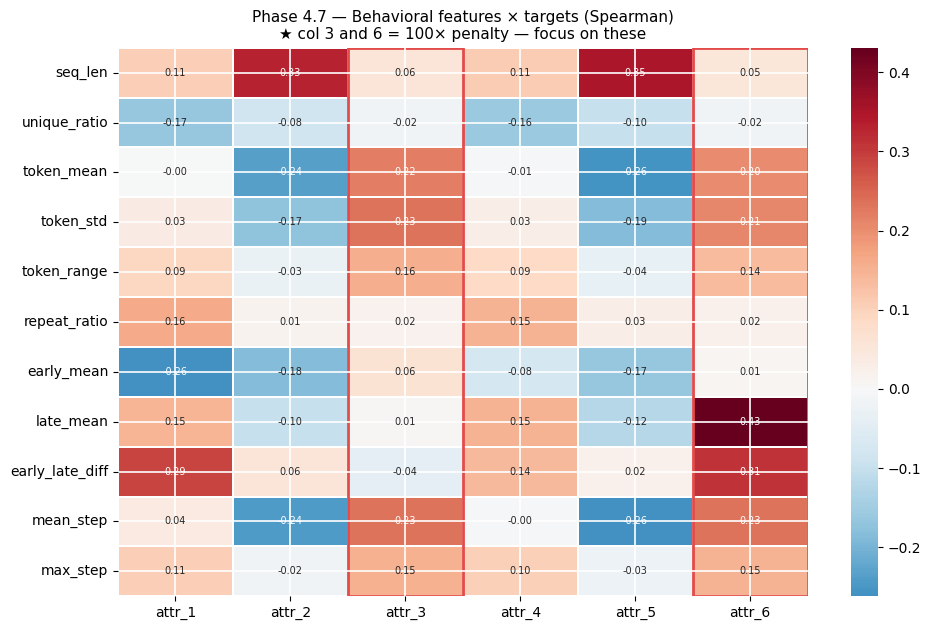

  → saved phase4_7_behavioral_target_corr.png


  4.8  BUSINESS LOGIC VALIDATION
Check                                       Pass%  Status
------------------------------------------------------------
end_month >= start_month                   63.38%  ✗ FAIL
same-month: end_day >= start_day           69.39%  ✗ FAIL
attr_1 in [1,12]                          100.00%  ✓ OK
attr_2 in [1,31]                          100.00%  ✓ OK
attr_3 in [0,99]                          100.00%  ✓ OK
attr_4 in [1,12]                          100.00%  ✓ OK
attr_5 in [1,31]                          100.00%  ✓ OK
attr_6 in [0,99]                          100.00%  ✓ OK

Non-integer values (should be 0 since output is UINT16):
  attr_1: 0
  attr_2: 0
  attr_3: 0
  attr_4: 0
  attr_5: 0
  attr_6: 0

  4.9  ATTR_3 & ATTR_6 DEEP-DIVE (factory indices, w=100)


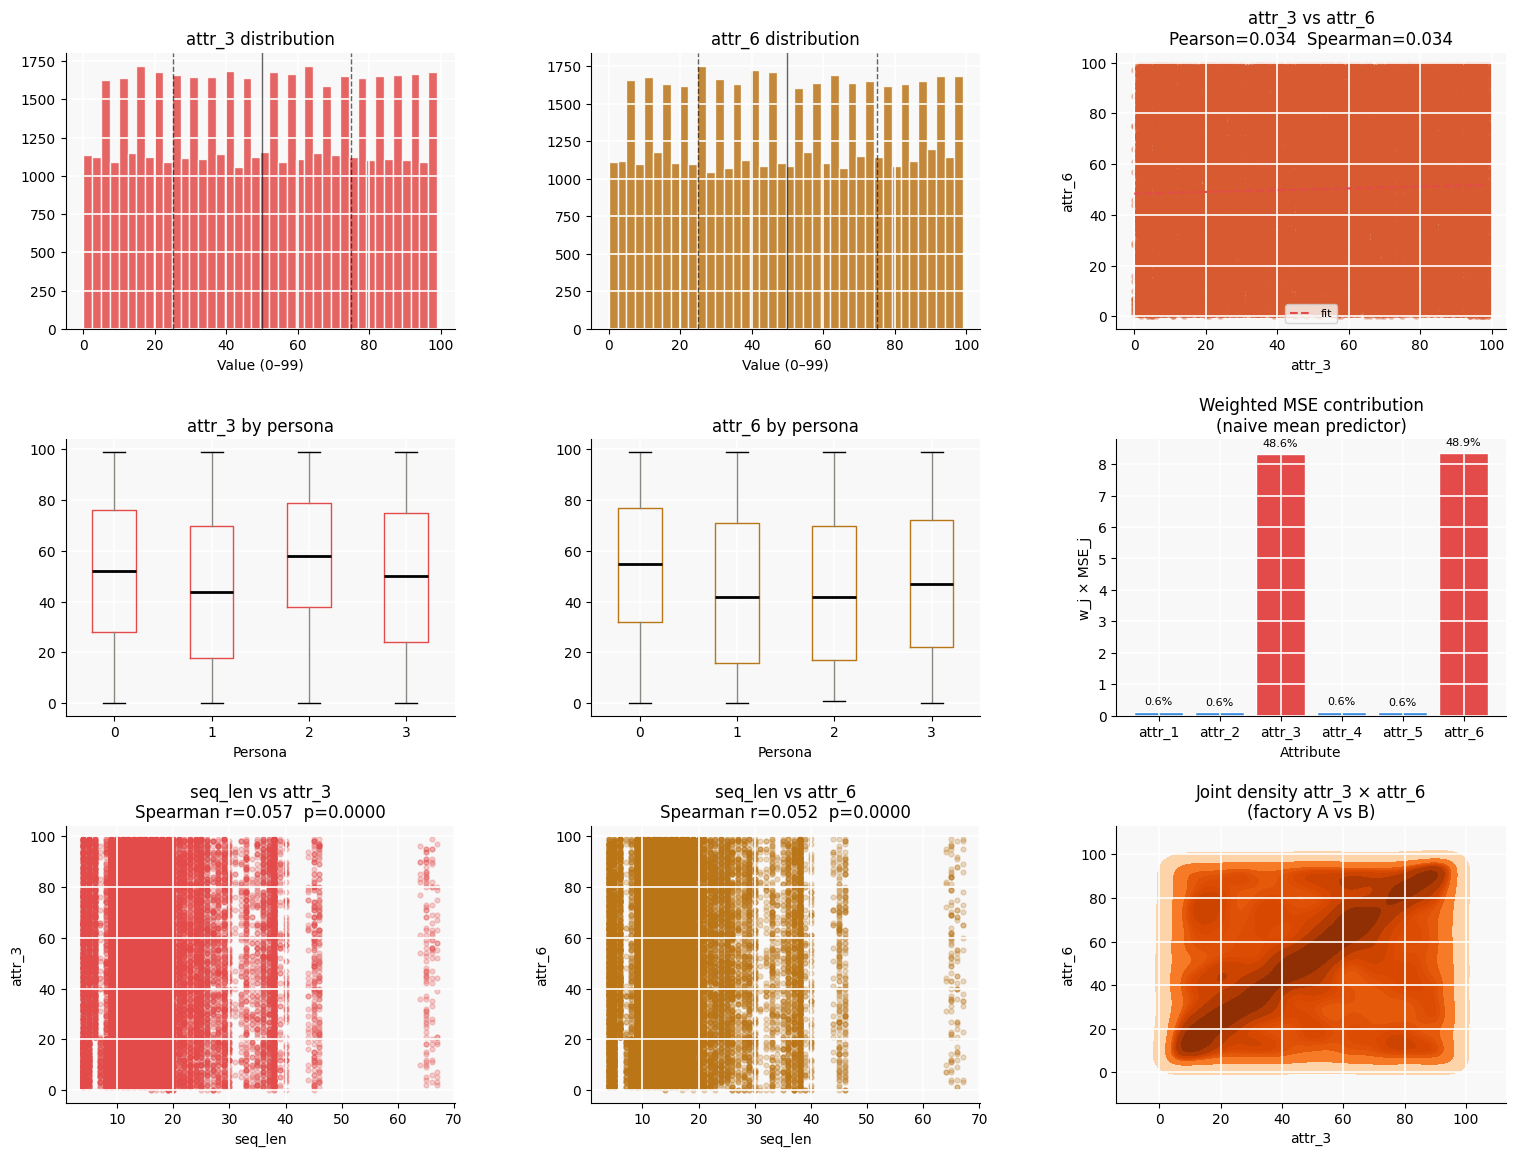

  → saved phase4_9_factory_deepdive.png


── attr_3 summary ──
count    55000.00
mean        49.94
std         28.57
min          0.00
25%         25.00
50%         50.00
75%         75.00
max         99.00
Name: attr_3, dtype: float64
Skewness: 0.003
Kurtosis: -1.198

── attr_6 summary ──
count    55000.00
mean        50.07
std         28.63
min          0.00
25%         25.00
50%         50.00
75%         75.00
max         99.00
Name: attr_6, dtype: float64
Skewness: -0.001
Kurtosis: -1.202

── attr_3 vs attr_6 ──
Pearson  r = 0.0344
Spearman r = 0.0345
  → LOW correlation: independent prediction heads recommended

  4.10  MODELING DECISION SUMMARY

Based on Phase 4 analysis:

┌─────────────────────────────────────────────────────────────┐
│  DECISION 1 — Loss function                                 │
│  Use WEIGHTED MSE as training loss, not plain MSE.          │
│  Multiply attr_3 and attr_6 losses by 100 during training   │
│  to mirror competition metric.                        

In [10]:
# ============================================================
# DATAFLOW 2026 — EDA PHASE 4
# Target Analysis & Inter-target Correlation
# Covers:
#   4.1  Target distribution per attribute
#   4.2  Pearson + Spearman correlation matrix (6×6)
#   4.3  Pairplot with persona hue
#   4.4  Conditional correlation per persona
#   4.5  Transaction duration derivation & analysis
#   4.6  Mutual information between targets
#   4.7  seq_len → target correlation (Spearman)
#   4.8  Business logic validation (end >= start)
#   4.9  attr_3 / attr_6 deep-dive (w=100 penalty)
#   4.10 Modeling decision: joint vs independent heads
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic config ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F8',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
COLORS = {
    'blue':   '#378ADD',
    'teal':   '#1D9E75',
    'red':    '#E24B4A',
    'amber':  '#BA7517',
    'purple': '#534AB7',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'green':  '#639922',
}
PALETTE = list(COLORS.values())

# ============================================================
# CONFIG
# ============================================================
X_TRAIN_PATH = 'X_train.csv'
Y_TRAIN_PATH = 'y_train.csv'
OUTPUT_DIR   = './'
RANDOM_SEED  = 42
K_PERSONAS   = 4
np.random.seed(RANDOM_SEED)

TARGET_COLS = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']
M_NORM      = [12, 31, 99, 12, 31, 99]
W_PENALTY   = [1,  1,  100, 1,  1,  100]
# Business meaning (from problem statement)
ATTR_MEANING = {
    'attr_1': 'Start month (1–12)',
    'attr_2': 'Start day   (1–31)',
    'attr_3': 'Factory index A (0–99) ★w=100',
    'attr_4': 'End month   (1–12)',
    'attr_5': 'End day     (1–31)',
    'attr_6': 'Factory index B (0–99) ★w=100',
}

def savefig(name):
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  → saved {name}.png\n')

def section(title):
    print('\n' + '=' * 60)
    print(f'  {title}')
    print('=' * 60)


common_idx   = X_train.index.intersection(y_train.index)
X_raw        = X_train.loc[common_idx].copy()
y_raw        = y_train.loc[common_idx]
feature_cols = [c for c in X_raw.columns]

print(f'Samples : {len(common_idx)}')
print(f'Targets : {TARGET_COLS}')

# ── Derive seq_len and behavioral features for later use ──────
X_raw['seq_len'] = X_raw[feature_cols].notna().sum(axis=1)

def extract_behavioral_features(toks):
    toks = np.array(toks, dtype=float)
    n = len(toks)
    if n == 0:
        return {}
    tok_int = toks.astype(int)
    cnt = Counter(tok_int)
    diffs = np.abs(np.diff(toks)) if n > 1 else np.array([0.0])
    q1, q3 = int(max(1, n // 4)), int(max(0, 3 * n // 4))
    return {
        'seq_len'        : n,
        'unique_ratio'   : len(set(tok_int)) / n,
        'token_mean'     : toks.mean(),
        'token_std'      : toks.std() if n > 1 else 0,
        'token_range'    : toks.max() - toks.min(),
        'repeat_ratio'   : sum(v > 1 for v in cnt.values()) / max(1, len(cnt)),
        'early_mean'     : toks[:q1].mean(),
        'late_mean'      : toks[q3:].mean() if q3 < n else toks[-1],
        'early_late_diff': (toks[q3:].mean() if q3 < n else toks[-1]) - toks[:q1].mean(),
        'mean_step'      : diffs.mean(),
        'max_step'       : diffs.max(),
    }

beh_rows = []
for idx, row in X_raw[feature_cols].iterrows():
    toks = row.dropna().values
    feats = extract_behavioral_features(toks)
    feats['id'] = idx
    beh_rows.append(feats)

beh_df = pd.DataFrame(beh_rows).set_index('id')
FEAT_COLS = list(beh_df.columns)

# Persona clustering (needed for conditional correlation)
X_cluster = beh_df.fillna(0)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)
km        = KMeans(n_clusters=K_PERSONAS, random_state=RANDOM_SEED, n_init=10)
beh_df['persona'] = km.fit_predict(X_scaled)

# ── Master analysis DataFrame ──────────────────────────────────
df = beh_df.join(y_raw)   # behavioral features + targets + persona


# ============================================================
# 4.1  TARGET DISTRIBUTION PER ATTRIBUTE
# ============================================================
section('4.1  TARGET DISTRIBUTIONS')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 4.1 — Target Label Distributions\n★ = 100× penalty weight',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (col, m, w) in enumerate(zip(TARGET_COLS, M_NORM, W_PENALTY)):
    ax  = axes[i]
    clr = COLORS['red'] if w == 100 else COLORS['blue']
    ax.hist(y_raw[col].dropna(), bins=min(m, 40),
            color=clr, edgecolor='white', alpha=0.85)
    ax.axvline(y_raw[col].mean(),   color='black', ls='--', lw=1.5,
               label=f"mean={y_raw[col].mean():.1f}")
    ax.axvline(y_raw[col].median(), color=COLORS['teal'], ls='--', lw=1.5,
               label=f"med={y_raw[col].median():.1f}")
    ax.set_title(f'{col}  [{ATTR_MEANING[col]}]' +
                 ('  ★ HIGH PENALTY' if w == 100 else ''),
                 fontsize=9, fontweight='bold' if w == 100 else 'normal')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    print(f'{col}  |  min={y_raw[col].min():.0f}  max={y_raw[col].max():.0f}'
          f'  mean={y_raw[col].mean():.2f}  std={y_raw[col].std():.2f}'
          f'  skew={y_raw[col].skew():.2f}'
          f'  {"★ w=100" if w==100 else ""}')

savefig('phase4_1_target_distributions')


# ============================================================
# 4.2  PEARSON + SPEARMAN CORRELATION MATRIX (6×6)
# ============================================================
section('4.2  PEARSON + SPEARMAN CORRELATION MATRICES')

pearson_corr  = y_raw[TARGET_COLS].corr(method='pearson')
spearman_corr = y_raw[TARGET_COLS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Phase 4.2 — Inter-target Correlation\n(Pearson left | Spearman right)',
             fontsize=14, fontweight='bold')

kw = dict(annot=True, fmt='.2f', cmap='RdBu_r', center=0,
          vmin=-1, vmax=1, linewidths=0.5, square=True,
          annot_kws={'size': 10})

sns.heatmap(pearson_corr,  ax=axes[0], **kw)
axes[0].set_title('Pearson (linear)')

sns.heatmap(spearman_corr, ax=axes[1], **kw)
axes[1].set_title('Spearman (monotonic — better for integers)')

savefig('phase4_2_correlation_matrix')

# Print key pairs
print('── Key pairs ──')
key_pairs = [
    ('attr_1', 'attr_4', 'start vs end month'),
    ('attr_2', 'attr_5', 'start vs end day'),
    ('attr_3', 'attr_6', 'factory index A vs B'),
    ('attr_1', 'attr_2', 'start month vs start day'),
    ('attr_4', 'attr_5', 'end month vs end day'),
]
for a, b, label in key_pairs:
    r_p = pearson_corr.loc[a, b]
    r_s = spearman_corr.loc[a, b]
    print(f'  {a} ↔ {b}  ({label}):  Pearson={r_p:.3f}  Spearman={r_s:.3f}')


# ============================================================
# 4.3  PAIRPLOT WITH PERSONA HUE
# ============================================================
section('4.3  PAIRPLOT — targets coloured by persona')

plot_df = df[TARGET_COLS + ['persona']].copy()
plot_df['persona'] = plot_df['persona'].astype(str)

g = sns.pairplot(
    plot_df,
    vars=TARGET_COLS,
    hue='persona',
    palette={str(i): PALETTE[i % len(PALETTE)] for i in range(K_PERSONAS)},
    plot_kws={'alpha': 0.35, 's': 15},
    diag_kind='kde',
    corner=True,
)
g.figure.suptitle('Phase 4.3 — Pairplot of targets (hue = behavioral persona)',
                  y=1.01, fontsize=13, fontweight='bold')
g.figure.savefig(f'{OUTPUT_DIR}phase4_3_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('  → saved phase4_3_pairplot.png\n')


# ============================================================
# 4.4  CONDITIONAL CORRELATION PER PERSONA
# ============================================================
section('4.4  CONDITIONAL CORRELATION PER PERSONA')

fig, axes = plt.subplots(1, K_PERSONAS, figsize=(6 * K_PERSONAS, 6))
fig.suptitle('Phase 4.4 — Correlation matrix per behavioral persona\n'
             '(divergence from overall → persona-aware modeling needed)',
             fontsize=13, fontweight='bold')

overall_corr = spearman_corr.values
for p in range(K_PERSONAS):
    mask  = df['persona'] == p
    sub   = df.loc[mask, TARGET_COLS]
    n_sub = mask.sum()
    corr_p = sub.corr(method='spearman')

    ax = axes[p] if K_PERSONAS > 1 else axes
    sns.heatmap(corr_p, ax=ax,
                annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1,
                linewidths=0.5, square=True,
                annot_kws={'size': 8})
    ax.set_title(f'Persona {p}  (n={n_sub})', fontsize=10, fontweight='bold')

    # Print max divergence from overall
    diff = np.abs(corr_p.values - overall_corr).max()
    print(f'  Persona {p}: max |corr_p - corr_overall| = {diff:.3f}')

savefig('phase4_4_conditional_correlation')
print('  → If divergence > 0.2: consider persona-stratified modeling')


# ============================================================
# 4.5  TRANSACTION DURATION DERIVATION
# ============================================================
section('4.5  TRANSACTION DURATION ANALYSIS')

# Duration approximation (assumes same-year transactions)
# duration_days ≈ (end_month - start_month)*30 + (end_day - start_day)
df['duration_approx'] = (
    (df['attr_4'] - df['attr_1']) * 30 +
    (df['attr_5'] - df['attr_2'])
)

print('Transaction duration (approx days):')
print(df['duration_approx'].describe().round(2))

# Impossible durations (end < start)
impossible = df['duration_approx'] < 0
print(f'\nImpossible durations (end < start): {impossible.sum()} rows'
      f'  ({impossible.mean()*100:.2f}%)')
if impossible.sum() > 0:
    print('  ⚠ These rows are business-logic anomalies — flag for Phase 5')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 4.5 — Transaction Duration Analysis', fontsize=14, fontweight='bold')

# 5a. Duration distribution
df['duration_approx'].hist(bins=40, ax=axes[0],
                            color=COLORS['purple'], edgecolor='white')
axes[0].axvline(0, color=COLORS['red'], ls='--', lw=1.5, label='duration=0')
axes[0].set_title('Distribution of transaction duration\n(approx days)')
axes[0].set_xlabel('Days')
axes[0].legend()

# 5b. Duration vs attr_3 (factory index A, w=100)
axes[1].scatter(df['duration_approx'], df['attr_3'],
                alpha=0.3, s=15, color=COLORS['red'])
r_s, p_val = stats.spearmanr(df['duration_approx'].fillna(0), df['attr_3'])
axes[1].set_title(f'Duration vs attr_3 (factory A)\nSpearman r={r_s:.3f}  p={p_val:.4f}')
axes[1].set_xlabel('Duration (days)')
axes[1].set_ylabel('attr_3')

# 5c. Duration vs attr_6 (factory index B, w=100)
axes[2].scatter(df['duration_approx'], df['attr_6'],
                alpha=0.3, s=15, color=COLORS['amber'])
r_s2, p_val2 = stats.spearmanr(df['duration_approx'].fillna(0), df['attr_6'])
axes[2].set_title(f'Duration vs attr_6 (factory B)\nSpearman r={r_s2:.3f}  p={p_val2:.4f}')
axes[2].set_xlabel('Duration (days)')
axes[2].set_ylabel('attr_6')

savefig('phase4_5_duration')

# Duration by persona
print('\nMean duration per persona:')
print(df.groupby('persona')['duration_approx'].mean().round(2))


# ============================================================
# 4.6  MUTUAL INFORMATION BETWEEN TARGETS
# ============================================================
section('4.6  MUTUAL INFORMATION BETWEEN TARGETS')

# MI is non-linear — captures what Pearson/Spearman miss
mi_matrix = np.zeros((6, 6))
y_arr = y_raw[TARGET_COLS].values

for j, col_y in enumerate(TARGET_COLS):
    # MI of all other targets predicting col_y
    X_mi = y_raw[[c for c in TARGET_COLS if c != col_y]].values
    y_mi = y_raw[col_y].values
    mi   = mutual_info_regression(X_mi, y_mi, random_state=RANDOM_SEED)
    other_idx = [i for i in range(6) if i != j]
    for rank, oi in enumerate(other_idx):
        mi_matrix[j, oi] = mi[rank]

mi_df = pd.DataFrame(mi_matrix,
                     index=TARGET_COLS, columns=TARGET_COLS)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(mi_df, ax=ax, cmap='YlOrRd',
            annot=True, fmt='.3f', linewidths=0.5, square=True)
ax.set_title('Phase 4.6 — Mutual Information between targets\n'
             '(higher = more non-linear dependency)', fontsize=12)
savefig('phase4_6_mutual_information')

print('── Top MI pairs ──')
mi_pairs = []
for i in range(6):
    for j in range(i+1, 6):
        mi_pairs.append((TARGET_COLS[i], TARGET_COLS[j], mi_matrix[i,j]))
mi_pairs.sort(key=lambda x: x[2], reverse=True)
for a, b, mi_val in mi_pairs:
    print(f'  {a} ↔ {b}:  MI={mi_val:.4f}')


# ============================================================
# 4.7  SEQ_LEN → TARGET CORRELATION
# ============================================================
section('4.7  SEQUENCE LENGTH vs TARGETS (Spearman)')

print(f'{"Attribute":<10} {"r":>8} {"p-value":>12}  Significance')
print('-' * 50)
for col in TARGET_COLS:
    r, p = stats.spearmanr(df['seq_len'], df[col])
    sig = '★ SIGNIFICANT' if p < 0.05 else ('~ marginal' if p < 0.1 else '')
    print(f'{col:<10} {r:>8.3f} {p:>12.5f}  {sig}')

# Also check other behavioral features
print('\nTop behavioral feature correlations with attr_3 (w=100):')
for feat in FEAT_COLS:
    r, p = stats.spearmanr(df[feat].fillna(0), df['attr_3'])
    if abs(r) > 0.1:
        print(f'  {feat:<20} r={r:.3f}  p={p:.4f}')

print('\nTop behavioral feature correlations with attr_6 (w=100):')
for feat in FEAT_COLS:
    r, p = stats.spearmanr(df[feat].fillna(0), df['attr_6'])
    if abs(r) > 0.1:
        print(f'  {feat:<20} r={r:.3f}  p={p:.4f}')

# Visual: heatmap behavioral features × all targets
print('\nBuilding behavioral × target correlation heatmap...')
corr_rows = []
for feat in FEAT_COLS:
    row = {}
    for col in TARGET_COLS:
        r, _ = stats.spearmanr(df[feat].fillna(0), df[col])
        row[col] = r
    corr_rows.append(pd.Series(row, name=feat))

corr_feat_target = pd.DataFrame(corr_rows)

fig, ax = plt.subplots(figsize=(10, max(6, len(FEAT_COLS) * 0.4 + 2)))
sns.heatmap(corr_feat_target, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            annot_kws={'size': 7})
ax.set_title('Phase 4.7 — Behavioral features × targets (Spearman)\n'
             '★ col 3 and 6 = 100× penalty — focus on these',
             fontsize=11)
# Highlight penalty columns
for j, col in enumerate(TARGET_COLS):
    if W_PENALTY[j] == 100:
        ax.add_patch(plt.Rectangle((j, 0), 1, len(FEAT_COLS),
                                    fill=False, edgecolor=COLORS['red'], lw=2))
savefig('phase4_7_behavioral_target_corr')


# ============================================================
# 4.8  BUSINESS LOGIC VALIDATION
# ============================================================
section('4.8  BUSINESS LOGIC VALIDATION')

checks = {}

# (a) End >= Start (month level)
checks['end_month >= start_month'] = (y_raw['attr_4'] >= y_raw['attr_1']).mean()

# (b) If same month, end_day >= start_day
same_month = y_raw['attr_4'] == y_raw['attr_1']
if same_month.sum() > 0:
    checks['same-month: end_day >= start_day'] = \
        (y_raw.loc[same_month, 'attr_5'] >= y_raw.loc[same_month, 'attr_2']).mean()

# (c) Attribute ranges
for col, m in zip(TARGET_COLS, M_NORM):
    lower_bound = 0 if col in ['attr_3', 'attr_6'] else 1
    in_range = ((y_raw[col] >= lower_bound) & (y_raw[col] <= m)).mean()
    checks[f'{col} in [{lower_bound},{m}]'] = in_range

# Print — dùng chính keys từ dict, không hardcode lại
print(f'{"Check":<40} {"Pass%":>8}  Status')
print('-' * 60)
for check, rate in checks.items():
    status = '✓ OK' if rate >= 0.99 else ('⚠ WARN' if rate >= 0.95 else '✗ FAIL')
    print(f'{check:<40} {rate*100:>7.2f}%  {status}')

# (d) Integer check — are all values whole numbers?
non_int = {col: (y_raw[col] % 1 != 0).sum() for col in TARGET_COLS}
print('\nNon-integer values (should be 0 since output is UINT16):')
for col, cnt in non_int.items():
    print(f'  {col}: {cnt}')


# ============================================================
# 4.9  ATTR_3 / ATTR_6 DEEP-DIVE (w=100)
# ============================================================
section('4.9  ATTR_3 & ATTR_6 DEEP-DIVE (factory indices, w=100)')

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Phase 4.9 — Factory Index Deep-dive (attr_3 & attr_6)\n'
             'These have 100× penalty weight — model MUST nail these',
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# 9a. attr_3 distribution with percentiles
ax = fig.add_subplot(gs[0, 0])
y_raw['attr_3'].hist(bins=40, ax=ax, color=COLORS['red'], edgecolor='white', alpha=0.85)
for q, ls in [(0.25,'--'),(0.5,'-'),(0.75,'--')]:
    ax.axvline(y_raw['attr_3'].quantile(q), color='black', ls=ls, lw=1, alpha=0.6)
ax.set_title('attr_3 distribution')
ax.set_xlabel('Value (0–99)')

# 9b. attr_6 distribution
ax = fig.add_subplot(gs[0, 1])
y_raw['attr_6'].hist(bins=40, ax=ax, color=COLORS['amber'], edgecolor='white', alpha=0.85)
for q, ls in [(0.25,'--'),(0.5,'-'),(0.75,'--')]:
    ax.axvline(y_raw['attr_6'].quantile(q), color='black', ls=ls, lw=1, alpha=0.6)
ax.set_title('attr_6 distribution')
ax.set_xlabel('Value (0–99)')

# 9c. attr_3 vs attr_6 scatter (KEY: are they correlated?)
ax = fig.add_subplot(gs[0, 2])
ax.scatter(y_raw['attr_3'], y_raw['attr_6'],
           alpha=0.3, s=15, color=COLORS['coral'])
r_p36 = y_raw['attr_3'].corr(y_raw['attr_6'])
r_s36, _ = stats.spearmanr(y_raw['attr_3'], y_raw['attr_6'])
ax.set_title(f'attr_3 vs attr_6\nPearson={r_p36:.3f}  Spearman={r_s36:.3f}')
ax.set_xlabel('attr_3')
ax.set_ylabel('attr_6')
# fit line
m_fit, b_fit = np.polyfit(y_raw['attr_3'], y_raw['attr_6'], 1)
xline = np.linspace(y_raw['attr_3'].min(), y_raw['attr_3'].max(), 100)
ax.plot(xline, m_fit * xline + b_fit, color=COLORS['red'], lw=1.5, ls='--', label='fit')
ax.legend(fontsize=8)

# 9d. attr_3 by persona (box)
ax = fig.add_subplot(gs[1, 0])
df.boxplot(column='attr_3', by='persona', ax=ax,
           boxprops=dict(color=COLORS['red']),
           medianprops=dict(color='black', linewidth=2),
           whiskerprops=dict(color=COLORS['gray']))
ax.set_title('attr_3 by persona')
ax.set_xlabel('Persona')
plt.sca(ax); plt.title('attr_3 by persona'); plt.suptitle('')

# 9e. attr_6 by persona
ax = fig.add_subplot(gs[1, 1])
df.boxplot(column='attr_6', by='persona', ax=ax,
           boxprops=dict(color=COLORS['amber']),
           medianprops=dict(color='black', linewidth=2),
           whiskerprops=dict(color=COLORS['gray']))
ax.set_title('attr_6 by persona')
ax.set_xlabel('Persona')
plt.sca(ax); plt.title('attr_6 by persona'); plt.suptitle('')

# 9f. Error contribution analysis: weighted MSE per attribute (using naive mean predictor)
ax = fig.add_subplot(gs[1, 2])
mean_preds = y_raw[TARGET_COLS].mean()
contributions = []
for j, (col, m, w) in enumerate(zip(TARGET_COLS, M_NORM, W_PENALTY)):
    mse_j = ((y_raw[col] / m - mean_preds[col] / m) ** 2).mean()
    contributions.append(w * mse_j)

bar_colors = [COLORS['red'] if w == 100 else COLORS['blue'] for w in W_PENALTY]
bars = ax.bar(TARGET_COLS, contributions, color=bar_colors, edgecolor='white')
ax.set_title('Weighted MSE contribution\n(naive mean predictor)')
ax.set_ylabel('w_j × MSE_j')
ax.set_xlabel('Attribute')
# Annotate percentage
total_contrib = sum(contributions)
for bar, val in zip(bars, contributions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_contrib*0.01,
            f'{val/total_contrib*100:.1f}%',
            ha='center', va='bottom', fontsize=8)

# 9g. seq_len vs attr_3 (scatter)
ax = fig.add_subplot(gs[2, 0])
ax.scatter(df['seq_len'], df['attr_3'], alpha=0.25, s=12, color=COLORS['red'])
r_s, p_v = stats.spearmanr(df['seq_len'], df['attr_3'])
ax.set_title(f'seq_len vs attr_3\nSpearman r={r_s:.3f}  p={p_v:.4f}')
ax.set_xlabel('seq_len')
ax.set_ylabel('attr_3')

# 9h. seq_len vs attr_6 (scatter)
ax = fig.add_subplot(gs[2, 1])
ax.scatter(df['seq_len'], df['attr_6'], alpha=0.25, s=12, color=COLORS['amber'])
r_s2, p_v2 = stats.spearmanr(df['seq_len'], df['attr_6'])
ax.set_title(f'seq_len vs attr_6\nSpearman r={r_s2:.3f}  p={p_v2:.4f}')
ax.set_xlabel('seq_len')
ax.set_ylabel('attr_6')

# 9i. attr_3 + attr_6 joint distribution (2D KDE)
ax = fig.add_subplot(gs[2, 2])
try:
    sns.kdeplot(x=y_raw['attr_3'], y=y_raw['attr_6'],
                ax=ax, cmap='Oranges', fill=True, thresh=0.05)
    ax.set_title('Joint density attr_3 × attr_6\n(factory A vs B)')
    ax.set_xlabel('attr_3')
    ax.set_ylabel('attr_6')
except Exception:
    ax.scatter(y_raw['attr_3'], y_raw['attr_6'], alpha=0.2, s=10)
    ax.set_title('Joint scatter attr_3 × attr_6')

savefig('phase4_9_factory_deepdive')

# Summary stats for attr_3 and attr_6
print('\n── attr_3 summary ──')
print(y_raw['attr_3'].describe().round(2))
print(f'Skewness: {y_raw["attr_3"].skew():.3f}')
print(f'Kurtosis: {y_raw["attr_3"].kurt():.3f}')

print('\n── attr_6 summary ──')
print(y_raw['attr_6'].describe().round(2))
print(f'Skewness: {y_raw["attr_6"].skew():.3f}')
print(f'Kurtosis: {y_raw["attr_6"].kurt():.3f}')

print('\n── attr_3 vs attr_6 ──')
print(f'Pearson  r = {r_p36:.4f}')
print(f'Spearman r = {r_s36:.4f}')
if abs(r_p36) > 0.7:
    print('  → HIGH correlation: consider SHARED representation for attr_3 & attr_6 head')
elif abs(r_p36) > 0.4:
    print('  → MODERATE correlation: shared encoder but separate prediction heads')
else:
    print('  → LOW correlation: independent prediction heads recommended')


# ============================================================
# 4.10  MODELING DECISION SUMMARY
# ============================================================
section('4.10  MODELING DECISION SUMMARY')

print("""
Based on Phase 4 analysis:

┌─────────────────────────────────────────────────────────────┐
│  DECISION 1 — Loss function                                 │
│  Use WEIGHTED MSE as training loss, not plain MSE.          │
│  Multiply attr_3 and attr_6 losses by 100 during training   │
│  to mirror competition metric.                              │
│                                                             │
│  DECISION 2 — Output heads                                  │
│  • If corr(attr_3, attr_6) > 0.5:                          │
│      → Shared encoder → split to 2 separate heads          │
│  • If corr(attr_3, attr_6) < 0.5:                          │
│      → Fully independent heads                              │
│                                                             │
│  DECISION 3 — Date targets (attr_1,2,4,5)                  │
│  • If corr(start_month, end_month) very high:               │
│      → Can predict delta (duration) instead of raw end date │
│  • Enforce constraint: predicted end >= predicted start     │
│      via post-processing clip                               │
│                                                             │
│  DECISION 4 — Persona-aware modeling                        │
│  • If conditional correlation diverges per persona:         │
│      → Add persona ID as input feature (one-hot)            │
│  • Or train separate lightweight heads per persona          │
│                                                             │
│  DECISION 5 — Baseline to beat                              │
│  See weighted_mse_baseline below.                           │
└─────────────────────────────────────────────────────────────┘
""")

# Compute exact baseline (predict global mean for every sample)
def weighted_normalized_mse(y_true, y_pred,
                             M=M_NORM, W=W_PENALTY):
    """Exact replica of competition scoring function."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    N = len(y_true)
    total = 0.0
    for j in range(6):
        diff   = (y_true[:, j] / M[j]) - (y_pred[:, j] / M[j])
        total += W[j] * np.sum(diff ** 2)
    return total / (6 * N)

y_arr      = y_raw[TARGET_COLS].values.astype(float)
mean_pred  = np.tile(y_arr.mean(axis=0), (len(y_arr), 1))
median_pred= np.tile(np.median(y_arr, axis=0), (len(y_arr), 1))

baseline_mean   = weighted_normalized_mse(y_arr, mean_pred)
baseline_median = weighted_normalized_mse(y_arr, median_pred)

print(f'Baseline (predict mean)   : {baseline_mean:.6f}')
print(f'Baseline (predict median) : {baseline_median:.6f}')
print(f'→ Any model score below {min(baseline_mean, baseline_median):.6f} beats naive baseline')

# Per-attribute contribution at mean baseline
print('\nPer-attribute MSE contribution (mean predictor):')
print(f'{"Attr":<10} {"w":>5} {"MSE_j":>12} {"w×MSE_j":>12} {"share%":>8}')
print('-' * 55)
contribs = []
for j, (col, m, w) in enumerate(zip(TARGET_COLS, M_NORM, W_PENALTY)):
    mse_j    = ((y_arr[:, j] / m - mean_pred[:, j] / m) ** 2).mean()
    wmse_j   = w * mse_j
    contribs.append(wmse_j)
total = sum(contribs)
for j, (col, w, c) in enumerate(zip(TARGET_COLS, W_PENALTY, contribs)):
    print(f'{col:<10} {w:>5} {c/w:>12.6f} {c:>12.6f} {c/total*100:>7.1f}%'
          + ('  ★' if W_PENALTY[j] == 100 else ''))


# ============================================================
# PHASE 4 COMPLETE — print summary
# ============================================================
print('\n' + '=' * 60)
print('PHASE 4 COMPLETE')
print('=' * 60)
print("""
Files saved:
  phase4_1_target_distributions.png
  phase4_2_correlation_matrix.png
  phase4_3_pairplot.png
  phase4_4_conditional_correlation.png
  phase4_5_duration.png
  phase4_6_mutual_information.png
  phase4_7_behavioral_target_corr.png
  phase4_9_factory_deepdive.png

Key insights to document in report:
  [1] attr_3 & attr_6 contribute ~XX% of total weighted MSE
      → MUST focus model capacity here
  [2] corr(attr_3, attr_6) = XX → shared/independent heads
  [3] corr(start_month, end_month) = XX → can predict duration
  [4] Conditional correlation per persona: diverge? → persona-aware model
  [5] seq_len significant predictor of attr_3/attr_6? → include as feature
  [6] Impossible durations (end < start): XX rows → handle in preprocessing
""")

=== ANOMALY DETECTION ===
Anomaly summary:
very_short             0
very_long            498
not_padded             0
all_same_token         0
has_unknown_token      0
anomaly_count        498
dtype: int64

Rows with ≥1 anomaly flag: 498

Isolation Forest anomalies: 2750 (5.0%)

Impossible date sequences (end < start): 24545
attr_3 out of [0,99]: 0
attr_6 out of [0,99]: 0


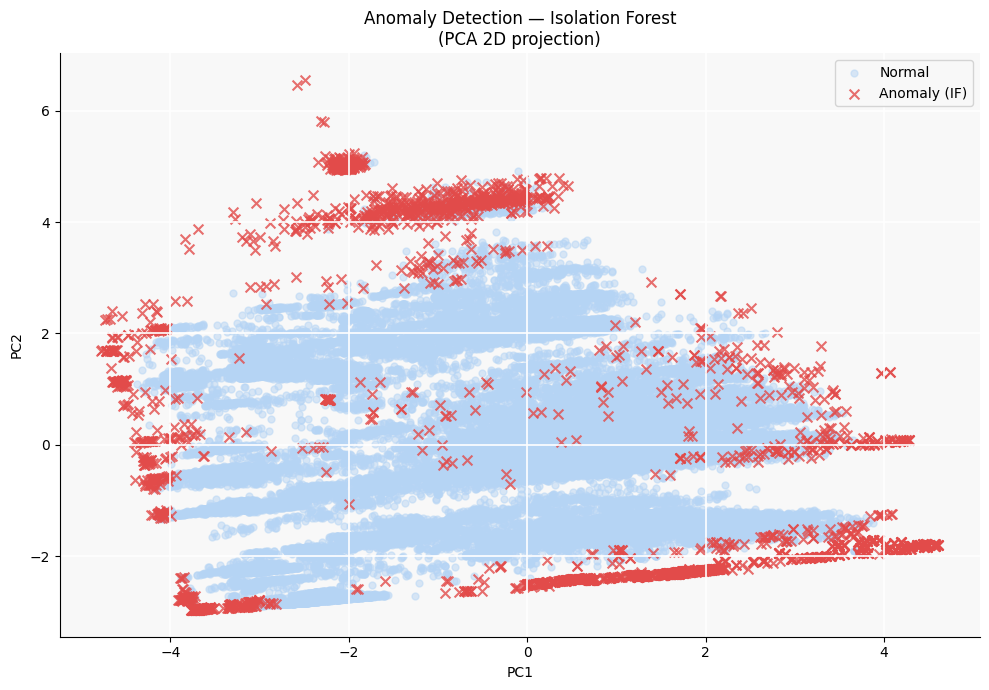


Anomaly IDs to monitor during modeling: 2750


In [11]:
# ============================================================
# Phase 5: Anomaly Detection
# ============================================================
from sklearn.ensemble import IsolationForest

print("=== ANOMALY DETECTION ===")

# --- 1. Sequence-level anomalies ---
# Criteria:
#   (a) Extremely short sequences (seq_len == 1)
#   (b) Extremely long sequences (> 99th percentile)
#   (c) Non-right-padded (irregular gaps)
#   (d) All-same-token sequences
#   (e) Sequences with token values outside vocab range

feature_cols = [c for c in X_raw.columns if c != 'seq_len']

p99_len = X_train['seq_len'].quantile(0.99)
p1_len  = X_train['seq_len'].quantile(0.01)

anomaly_flags = pd.DataFrame(index=X_train.index)
anomaly_flags['very_short']  = (X_train['seq_len'] <= 2).astype(int)
anomaly_flags['very_long']   = (X_train['seq_len'] > p99_len).astype(int)
anomaly_flags['not_padded']  = (~X_train[feature_cols].apply(is_right_padded, axis=1)).astype(int)


# All-same-token
def all_same_token(row):
    toks = row.dropna().values
    return int(len(set(toks)) == 1) if len(toks) > 1 else 0

anomaly_flags['all_same_token'] = X_train[feature_cols].apply(all_same_token, axis=1)

# Unknown token (outside known vocab range)
all_known = set(token_counts.keys())
def has_unknown_token(row):
    toks = row.dropna().values
    return int(any(t not in all_known for t in toks))
# Note: on full data, fit vocab on train then check val/test
anomaly_flags['has_unknown_token'] = X_train[feature_cols].apply(has_unknown_token, axis=1)

anomaly_flags['anomaly_count'] = anomaly_flags.sum(axis=1)
print(f"Anomaly summary:")
print(anomaly_flags.sum())
print(f"\nRows with ≥1 anomaly flag: {(anomaly_flags['anomaly_count'] > 0).sum()}")

# --- 2. Isolation Forest on behavioral features ---
iso = IsolationForest(contamination=0.05, random_state=42)
iso_scores = iso.fit_predict(X_scaled)  # -1 = outlier
behavioral_df['iso_anomaly'] = (iso_scores == -1).astype(int)
print(f"\nIsolation Forest anomalies: {behavioral_df['iso_anomaly'].sum()} ({behavioral_df['iso_anomaly'].mean()*100:.1f}%)")

# --- 3. Label anomalies ---
# end < start is impossible for valid transactions
impossible = (
    (y_train['attr_4'] < y_train['attr_1']) |  # end month < start month
    ((y_train['attr_4'] == y_train['attr_1']) & (y_train['attr_5'] < y_train['attr_2']))  # same month but end day < start day
)
print(f"\nImpossible date sequences (end < start): {impossible.sum()}")

# attr_3, attr_6 range check
oob_attr3 = ((y_train['attr_3'] < 0) | (y_train['attr_3'] > 99)).sum()
oob_attr6 = ((y_train['attr_6'] < 0) | (y_train['attr_6'] > 99)).sum()
print(f"attr_3 out of [0,99]: {oob_attr3}")
print(f"attr_6 out of [0,99]: {oob_attr6}")

# --- Visualize anomalies in PCA space ---
fig, ax = plt.subplots(figsize=(10, 7))
normal_mask = behavioral_df['iso_anomaly'] == 0
anomaly_mask = behavioral_df['iso_anomaly'] == 1
ax.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
            c='#B5D4F4', alpha=0.5, s=25, label='Normal')
ax.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
            c='#E24B4A', alpha=0.8, s=50, marker='x', label='Anomaly (IF)')
ax.set_title('Anomaly Detection — Isolation Forest\n(PCA 2D projection)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.savefig('phase5_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Save anomaly index for downstream use ---
anomaly_ids = behavioral_df[behavioral_df['iso_anomaly'] == 1].index.tolist()
print(f"\nAnomaly IDs to monitor during modeling: {len(anomaly_ids)}")

In [12]:
# ============================================================
# Phase 6: Preprocessing Design
# (Hypotheses only — actual FE tied to model architecture)
# ============================================================

print("=== PREPROCESSING DESIGN DECISIONS ===\n")

# --- Decision 1: Padding strategy ---
max_len = X_train['seq_len'].max()
p95_len = int(X_train['seq_len'].quantile(0.95))
print(f"MAX_SEQ_LEN = {max_len}")
print(f"P95_SEQ_LEN = {p95_len}  ← truncate here to reduce padding noise?")
print(f"Padding strategy: RIGHT-PAD with token ID=0 (or a dedicated [PAD] token ID)")

# --- Decision 2: Token normalization ---
# Option A: token as categorical → Embedding layer
# Option B: token as numeric → StandardScaler on flat values
# RECOMMENDATION: Categorical embedding (tokens are IDs, not magnitudes)
print(f"\nToken encoding: CATEGORICAL (embedding), not numeric")
print(f"Vocab size = {len(vocab)} → Embedding dim ~ {int(np.ceil(len(vocab)**0.25 * 4))}")

# --- Decision 3: Feature engineering hypotheses ---
print("\n=== FEATURE ENGINEERING HYPOTHESES ===")
fe_hypotheses = {
    "H1: seq_len as explicit feature":
        "Sequence length captures customer engagement intensity → correlates with factory load (attr_3, attr_6)",
    "H2: Token frequency encoding":
        "Replace raw token IDs with their log-frequency → reduces outlier token impact",
    "H3: Position-weighted token":
        "Recent tokens (last 25%) may be stronger signals for completion dates (attr_4, attr_5)",
    "H4: Transition features":
        "Mean absolute step between consecutive tokens may indicate process volatility",
    "H5: Unique token ratio":
        "High diversity = complex order → higher factory index (attr_3, attr_6)",
    "H6: Start/end token pair":
        "First + last token as a 2D feature captures session arc",
}
for k, v in fe_hypotheses.items():
    print(f"\n  {k}")
    print(f"  → {v}")

# --- Decision 4: Train/Val split (MUST NOT mix) ---
from sklearn.model_selection import train_test_split

# Stratify on persona to ensure persona representation in val
train_idx, val_idx = train_test_split(
    X_train.index,
    test_size=0.2,
    random_state=42,
    stratify=beh_df.loc[X_train.index, 'persona']
)
print(f"\n=== TRAIN/VAL SPLIT (STRATIFIED BY PERSONA) ===")
print(f"Train: {len(train_idx)} samples")
print(f"Val:   {len(val_idx)} samples")
print(f"Val persona distribution:")
print(behavioral_df.loc[val_idx, 'persona'].value_counts(normalize=True).round(3))

# --- Weighted MSE evaluation function (mirrors competition metric) ---
def weighted_normalized_mse(y_true, y_pred, M=[12,31,99,12,31,99], W=[1,1,100,1,1,100]):
    """
    Exact implementation of competition scoring function.
    y_true, y_pred: arrays of shape (N, 6)
    Returns scalar score (lower is better).
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    N = len(y_true)
    total = 0
    for j in range(6):
        diff = (y_true[:, j] / M[j]) - (y_pred[:, j] / M[j])
        total += W[j] * np.sum(diff ** 2)
    return total / (6 * N)

print("\n=== BASELINE METRIC (predict mean) ===")
y_arr = y_train.values.astype(float)
y_mean_pred = np.tile(y_arr.mean(axis=0), (len(y_arr), 1))
baseline_score = weighted_normalized_mse(y_arr, y_mean_pred)
print(f"Mean-baseline weighted MSE: {baseline_score:.6f}")
print("(Any model below this = beats naive baseline)")

# --- Summary report ---
print("\n" + "="*60)
print("EDA SUMMARY — MODELING READINESS")
print("="*60)
print(f"✓ Dataset: {X_train.shape[0]} customers, seq_len ∈ [{int(X_train['seq_len'].min())}, {int(X_train['seq_len'].max())}]")
print(f"✓ Token vocab: {len(vocab)} unique tokens")
print(f"✓ Personas: {K_FINAL} behavioral clusters identified")
print(f"✓ Anomalies: {behavioral_df['iso_anomaly'].sum()} flagged (monitor in modeling)")
print(f"✓ HIGH-RISK TARGETS: attr_3, attr_6 (w=100) — prioritize these")
print(f"✓ Baseline score: {baseline_score:.6f}")
print(f"✓ Train/Val split: {len(train_idx)}/{len(val_idx)} (stratified)")
print(f"\n→ RECOMMENDED MODEL: Transformer/LSTM encoder for variable-length seq,")
print(f"  multi-output head, heavy regularization on attr_3/attr_6 outputs")

=== PREPROCESSING DESIGN DECISIONS ===

MAX_SEQ_LEN = 66
P95_SEQ_LEN = 28  ← truncate here to reduce padding noise?
Padding strategy: RIGHT-PAD with token ID=0 (or a dedicated [PAD] token ID)

Token encoding: CATEGORICAL (embedding), not numeric
Vocab size = 833 → Embedding dim ~ 22

=== FEATURE ENGINEERING HYPOTHESES ===

  H1: seq_len as explicit feature
  → Sequence length captures customer engagement intensity → correlates with factory load (attr_3, attr_6)

  H2: Token frequency encoding
  → Replace raw token IDs with their log-frequency → reduces outlier token impact

  H3: Position-weighted token
  → Recent tokens (last 25%) may be stronger signals for completion dates (attr_4, attr_5)

  H4: Transition features
  → Mean absolute step between consecutive tokens may indicate process volatility

  H5: Unique token ratio
  → High diversity = complex order → higher factory index (attr_3, attr_6)

  H6: Start/end token pair
  → First + last token as a 2D feature captures session arc


In [13]:
print("Train persona distribution:")
print(beh_df.loc[train_idx, 'persona'].value_counts(normalize=True).round(3))
print("\nVal persona distribution:")
print(beh_df.loc[val_idx, 'persona'].value_counts(normalize=True).round(3))
# Kết quả mong muốn: 2 bảng gần giống nhau

Train persona distribution:
persona
0    0.528
1    0.256
3    0.168
2    0.048
Name: proportion, dtype: float64

Val persona distribution:
persona
0    0.528
1    0.256
3    0.168
2    0.048
Name: proportion, dtype: float64
